# DFW Commercial Rooftop Solar Energy Potential — Analysis Notebook
### Dataset: `final_solar_estimates.csv` | 8,612 Buildings | 11 Counties | 6 Building Types


## Section 1 — Setup

In [ ]:
!pip install matplotlib seaborn pandas numpy scipy --quiet
print("Ready.")

Ready.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.colors as mcolors
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : '#333333',
    'axes.labelcolor'  : '#222222',
    'axes.titlecolor'  : '#111111',
    'axes.grid'        : False,
    'text.color'       : '#222222',
    'xtick.color'      : '#333333',
    'ytick.color'      : '#333333',
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'legend.facecolor' : 'white',
    'legend.edgecolor' : '#cccccc',
    'legend.labelcolor': '#222222',
})

# Building type colours — same palette as the folium HTML map
BLDG = {
    'commercial' : '#3182bd',
    'retail'     : '#e6550d',
    'warehouse'  : '#31a354',
    'industrial' : '#756bb1',
    'office'     : '#636363',
    'supermarket': '#d62728',
}

def county_blues(n):
    """Returns n shades of blue, darkest first (for descending-sorted charts)."""
    return [mcolors.to_hex(c)
            for c in plt.cm.Blues(np.linspace(0.85, 0.30, n))]

TIER = {'Low':'#d73027','Medium':'#fee08b','High':'#1a9850'}
print("Style configured.")

Style configured.


## Section 2 — Data Load

In [ ]:
from google.colab import files
print("Upload final_solar_estimates.csv:")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df['county_short'] = (df['county']
                      .str.replace(', Texas','', regex=False)
                      .str.replace(' County','', regex=False))

# Derived columns used throughout
df['Annual_Revenue_USD']  = df['Annual_kWh'] * 0.12
df['Trees_Equiv']          = df['Carbon_Reduction_kgCO2'] / 21.77
df['CO2_per_sqft']         = df['Carbon_Reduction_kgCO2'] / df['Building_Sq_Ft']
df['MWh_per_M_USD']        = df['Annual_MWh'] / df['Estimated_Solar_Cost_Million_USD']

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Building types: {df['building'].value_counts().to_dict()}")
print(f"Counties: {df['county_short'].nunique()}")

Upload final_solar_estimates.csv:


Saving final_solar_estimates.csv to final_solar_estimates.csv
Loaded: 8,612 rows × 32 columns
Building types: {'commercial': 2562, 'retail': 2260, 'warehouse': 1929, 'industrial': 1283, 'office': 576, 'supermarket': 2}
Counties: 11


## Section 3 — Key Portfolio Statistics

In [ ]:
kpis = [
    ("Total Buildings Analysed",     f"{len(df):,}"),
    ("Counties Covered",             f"{df['county'].nunique()}"),
    ("Building Types",               f"{df['building'].nunique()}"),
    ("Total Annual Energy",          f"{df['Annual_MWh'].sum()/1e6:.3f} Million MWh/year"),
    ("Total CO2 Avoided",            f"{df['Carbon_Reduction_tonsCO2'].sum()/1e6:.3f} Million metric tons/year"),
    ("Total Installation Cost",      f"${df['Estimated_Solar_Cost_USD'].sum()/1e9:.2f} Billion USD"),
    ("Households Powered (ERCOT)",   f"{df['Households_Powered'].sum():,.0f}"),
    ("Median Building Size",         f"{df['Building_Sq_Ft'].median()/1000:.0f}K sq ft"),
    ("Median Annual Output",         f"{df['Annual_MWh'].median():,.0f} MWh/yr per building"),
]
print("=" * 60)
print("  DFW COMMERCIAL ROOFTOP SOLAR — PORTFOLIO SUMMARY")
print("=" * 60)
for label, value in kpis:
    print(f"  {label:<35} {value}")
print("=" * 60)

  DFW COMMERCIAL ROOFTOP SOLAR — PORTFOLIO SUMMARY
  Total Buildings Analysed            8,612
  Counties Covered                    11
  Building Types                      6
  Total Annual Energy                 15.706 Million MWh/year
  Total CO2 Avoided                   5.261 Million metric tons/year
  Total Installation Cost             $19.56 Billion USD
  Households Powered (ERCOT)          1,194,170
  Median Building Size                42K sq ft
  Median Annual Output                822 MWh/yr per building


## Section 4 — Building Type Analysis

**Why this analysis was done:**
The DFW portfolio contains six categories of large commercial and industrial buildings.
Before recommending a deployment strategy, we need to understand whether each category
contributes to solar potential in proportion to its share of the building stock —
or whether some categories punch far above (or below) their weight.
This matters because municipal incentive programmes and utility procurement contracts
are typically designed around building categories. If a programme targets commercial
buildings equally, it may miss the much larger energy opportunity concentrated in
warehouses and industrial facilities.

The four panels below examine count, total energy output, total CO₂ avoided, and
total installation cost — the four dimensions any deployment decision-maker needs
to see simultaneously.

**Key finding:** Warehouse and industrial buildings together represent 37.3% of the portfolio
by count but deliver 63.8% of total annual energy — a 1.7× concentration factor.
Commercial and retail buildings are the opposite: 56% of count, 33% of energy.
Count-based targeting would systematically misallocate deployment resources.

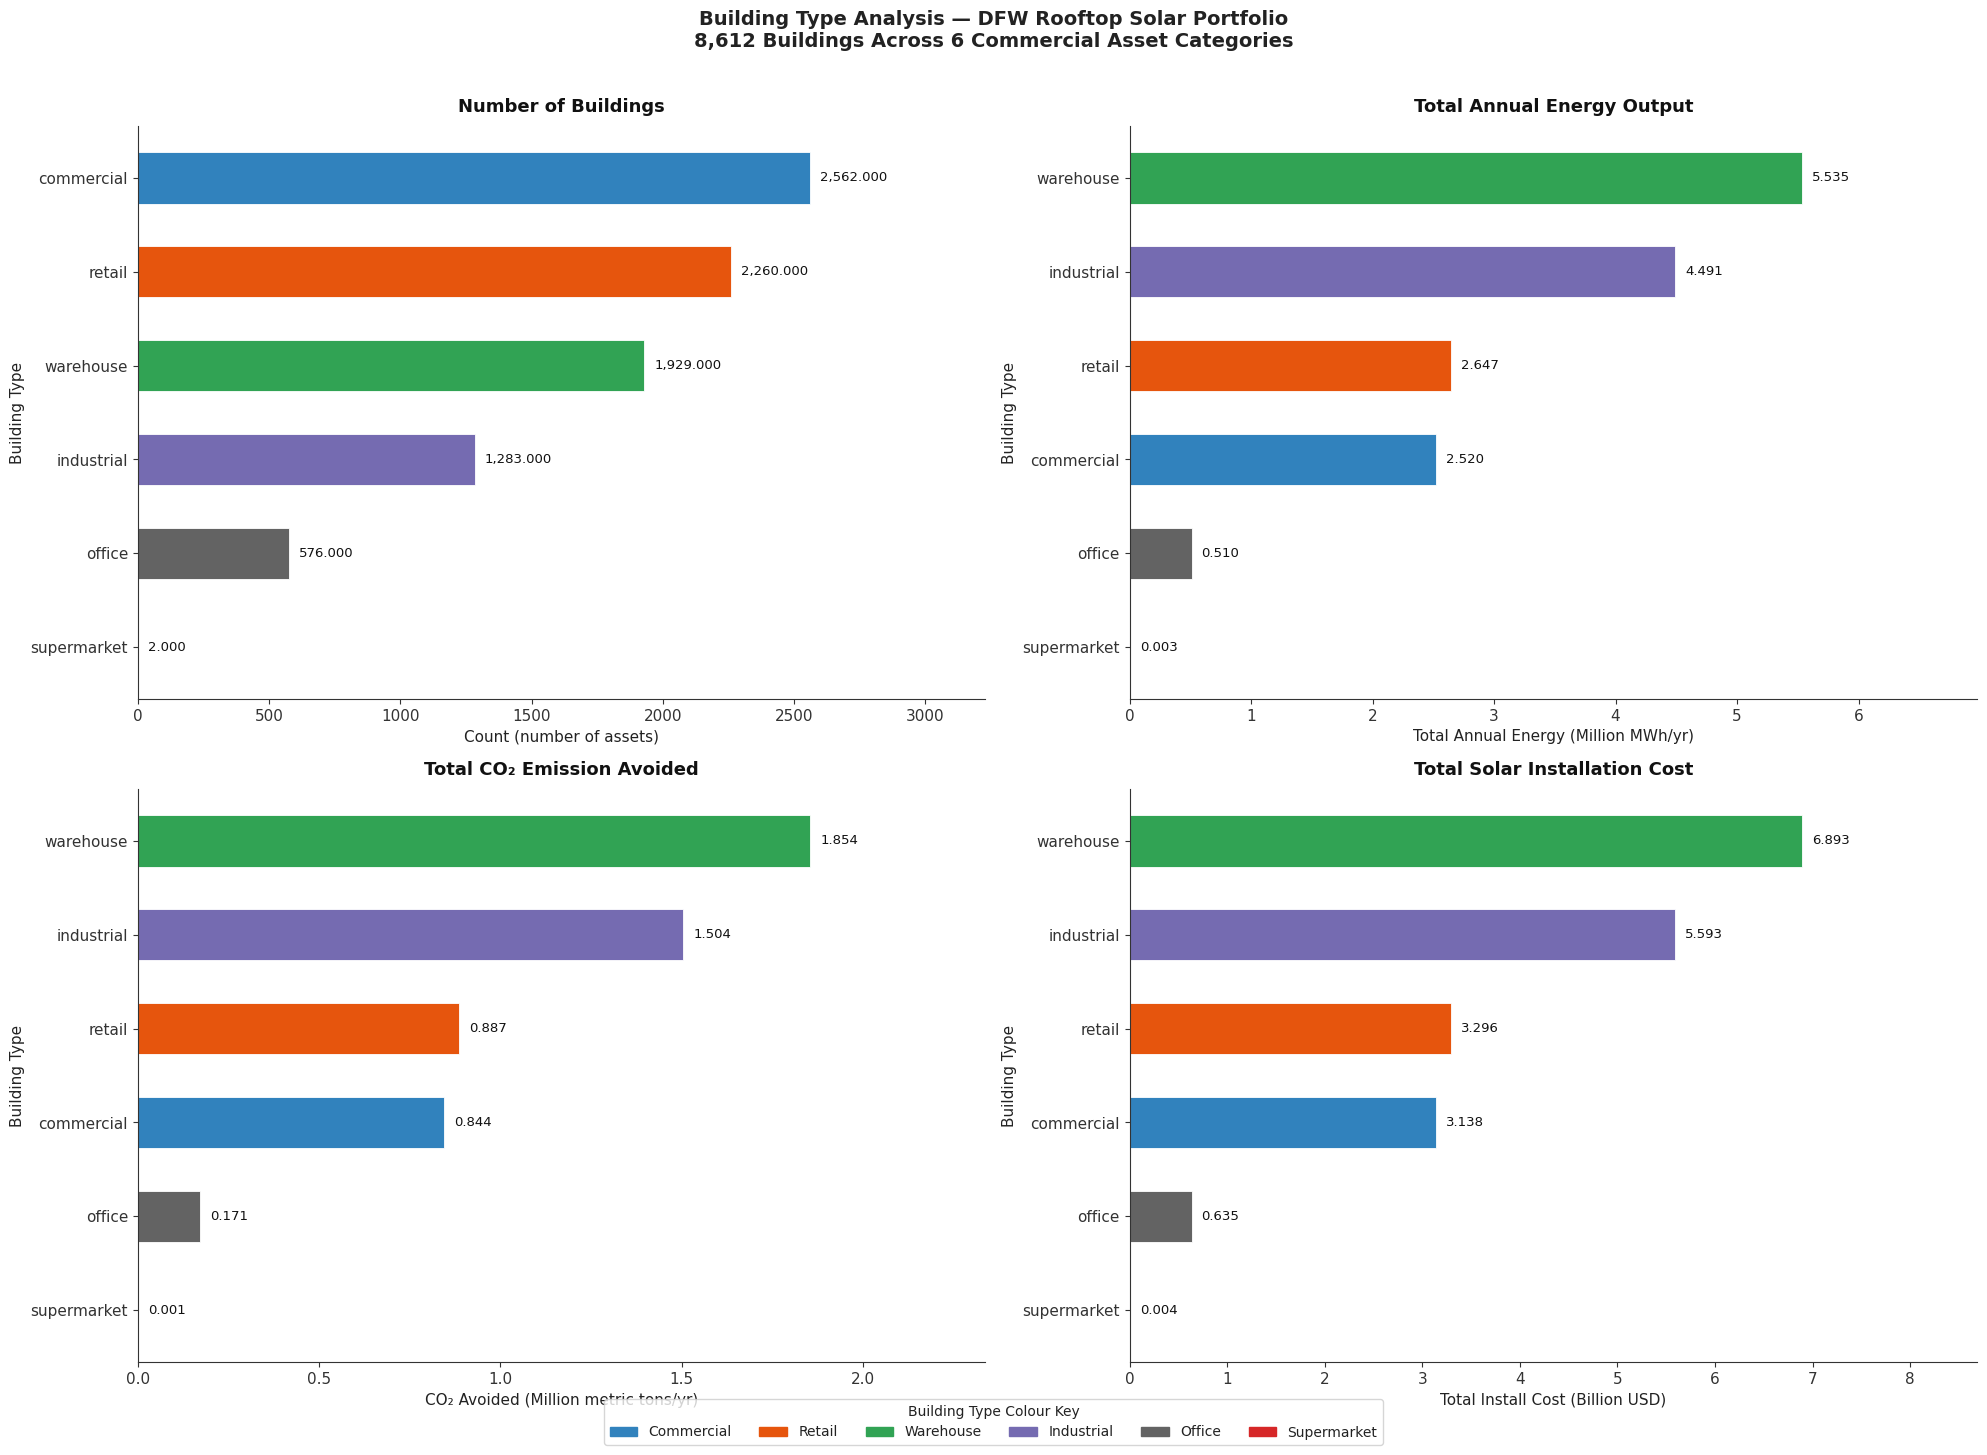

Saved: 01_building_type.png


In [ ]:
# ── Building type aggregation ────────────────────────────────────────────────
bt = df.groupby('building').agg(
    Count        = ('name','count'),
    Total_MWh    = ('Annual_MWh','sum'),
    Total_CO2    = ('Carbon_Reduction_tonsCO2','sum'),
    Total_Cost_M = ('Estimated_Solar_Cost_Million_USD','sum'),
).sort_values('Total_MWh', ascending=False)

panels = [
    (bt['Count'],            'Number of Buildings',             'Count (number of assets)'),
    (bt['Total_MWh']/1e6,   'Total Annual Energy Output',       'Total Annual Energy (Million MWh/yr)'),
    (bt['Total_CO2']/1e6,   'Total CO₂ Emission Avoided',       'CO₂ Avoided (Million metric tons/yr)'),
    (bt['Total_Cost_M']/1000,'Total Solar Installation Cost',   'Total Install Cost (Billion USD)'),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Building Type Analysis — DFW Rooftop Solar Portfolio\n'
             '8,612 Buildings Across 6 Commercial Asset Categories',
             fontsize=14, fontweight='bold', y=1.01)
axs = axes.flatten()

for ax, (vals, title, xlabel) in zip(axs, panels):
    sorted_vals = vals.sort_values(ascending=True)   # largest bar at top
    clrs = [BLDG.get(b, '#888') for b in sorted_vals.index]
    bars = ax.barh(sorted_vals.index, sorted_vals.values,
                   color=clrs, edgecolor='white', linewidth=0.6, height=0.55)
    for bar, val in zip(bars, sorted_vals.values):
        ax.text(bar.get_width() + sorted_vals.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.3f}', va='center', fontsize=9.5, color='#111111')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Building Type')
    ax.set_xlim(0, sorted_vals.max() * 1.26)
    ax.spines[['top','right']].set_visible(False)

patches = [mpatches.Patch(color=v, label=k.capitalize()) for k,v in BLDG.items()]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           title='Building Type Colour Key', title_fontsize=10,
           bbox_to_anchor=(0.5,-0.02), frameon=True)
plt.tight_layout()
plt.savefig('01_building_type.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 01_building_type.png")

## Section —  County Level

**Why this replication matters:**
Building type tells us *what* to target. County tells us *where*.
By replicating the same four metrics at county scale, the reader can
immediately see which geographic jurisdictions offer the largest
energy, carbon, and cost opportunities — without needing to look at a separate section.

The core finding is a strong geographic concentration: Dallas County alone
contains 51.7% of total portfolio energy from 58.8% of all buildings.
The four core counties (Dallas, Tarrant, Denton, Collin) together account
for 94.9% of total annual energy output — making the metropolitan core
the unambiguous first target for any regional deployment programme.

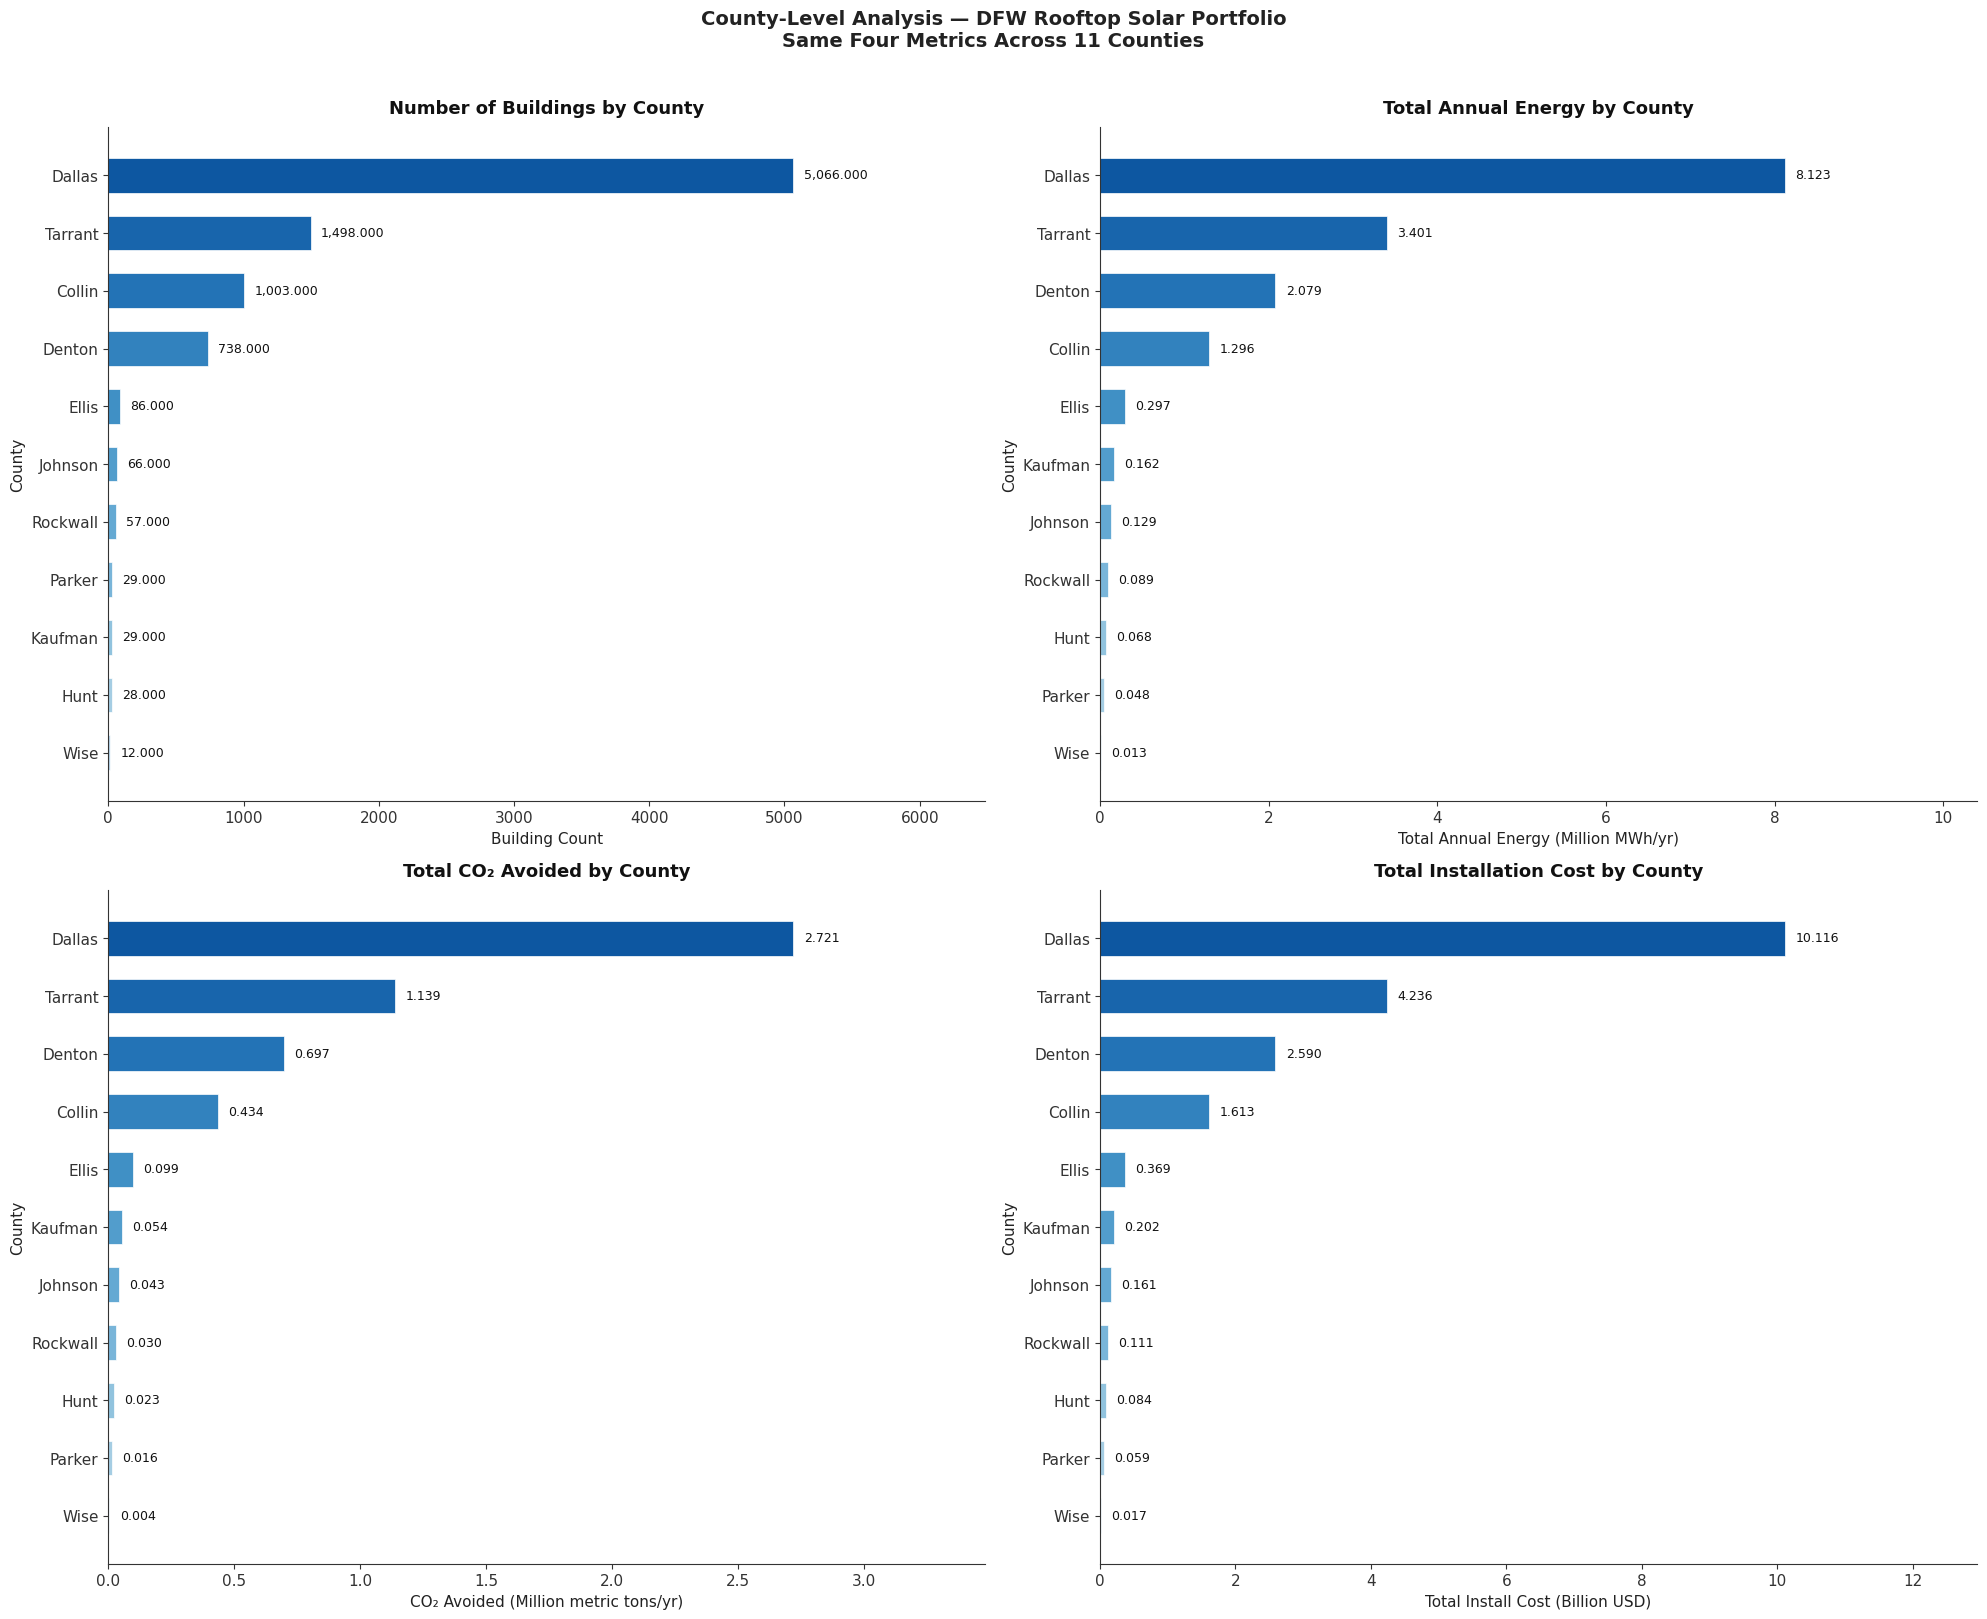

Saved: 01b_county_panels.png


In [ ]:
# ── County aggregation for same four panels ──────────────────────────────────
cy_bt = df.groupby('county_short').agg(
    Count        = ('name','count'),
    Total_MWh    = ('Annual_MWh','sum'),
    Total_CO2    = ('Carbon_Reduction_tonsCO2','sum'),
    Total_Cost_B = ('Estimated_Solar_Cost_USD','sum'),
).sort_values('Total_MWh', ascending=False)

panels_cy = [
    (cy_bt['Count'],             'Number of Buildings by County',       'Building Count'),
    (cy_bt['Total_MWh']/1e6,    'Total Annual Energy by County',        'Total Annual Energy (Million MWh/yr)'),
    (cy_bt['Total_CO2']/1e6,    'Total CO₂ Avoided by County',          'CO₂ Avoided (Million metric tons/yr)'),
    (cy_bt['Total_Cost_B']/1e9, 'Total Installation Cost by County',    'Total Install Cost (Billion USD)'),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('County-Level Analysis — DFW Rooftop Solar Portfolio\n'
             'Same Four Metrics Across 11 Counties',
             fontsize=14, fontweight='bold', y=1.01)
axs = axes.flatten()

for ax, (vals, title, xlabel) in zip(axs, panels_cy):
    sorted_vals = vals.sort_values(ascending=True)   # largest at top
    n = len(sorted_vals)
    clrs = county_blues(n)[::-1]   # darkest = largest value
    bars = ax.barh(sorted_vals.index, sorted_vals.values,
                   color=clrs, edgecolor='white', linewidth=0.5, height=0.6)
    for bar, val in zip(bars, sorted_vals.values):
        ax.text(bar.get_width() + sorted_vals.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,.3f}', va='center', fontsize=9, color='#111111')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('County')
    ax.set_xlim(0, sorted_vals.max() * 1.28)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('01b_county_panels.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 01b_county_panels.png")

## Section 4c — Building Type Share: Count vs Energy

**Why this chart was made:**
A policymaker or utility planner who allocates incentives by building *count*
will make fundamentally different decisions than one who allocates by energy *potential*.
These two pie charts make that gap visible in a single image.

The left pie shows what share of the 8,612 buildings each type represents.
The right pie shows what share of total annual energy each type generates.

If the two pies looked identical, count would be a valid proxy for energy potential.
They look very different — and that divergence is the central methodological
argument of this paper. The supermarket category (Kroger and Sprouts Farmers Market —
the only two buildings of this type in the DFW dataset above 20,000 sq ft)
represents 0.023% of buildings and 0.018% of total energy, but is shown
explicitly because excluding it would misrepresent the full scope of the analysis.

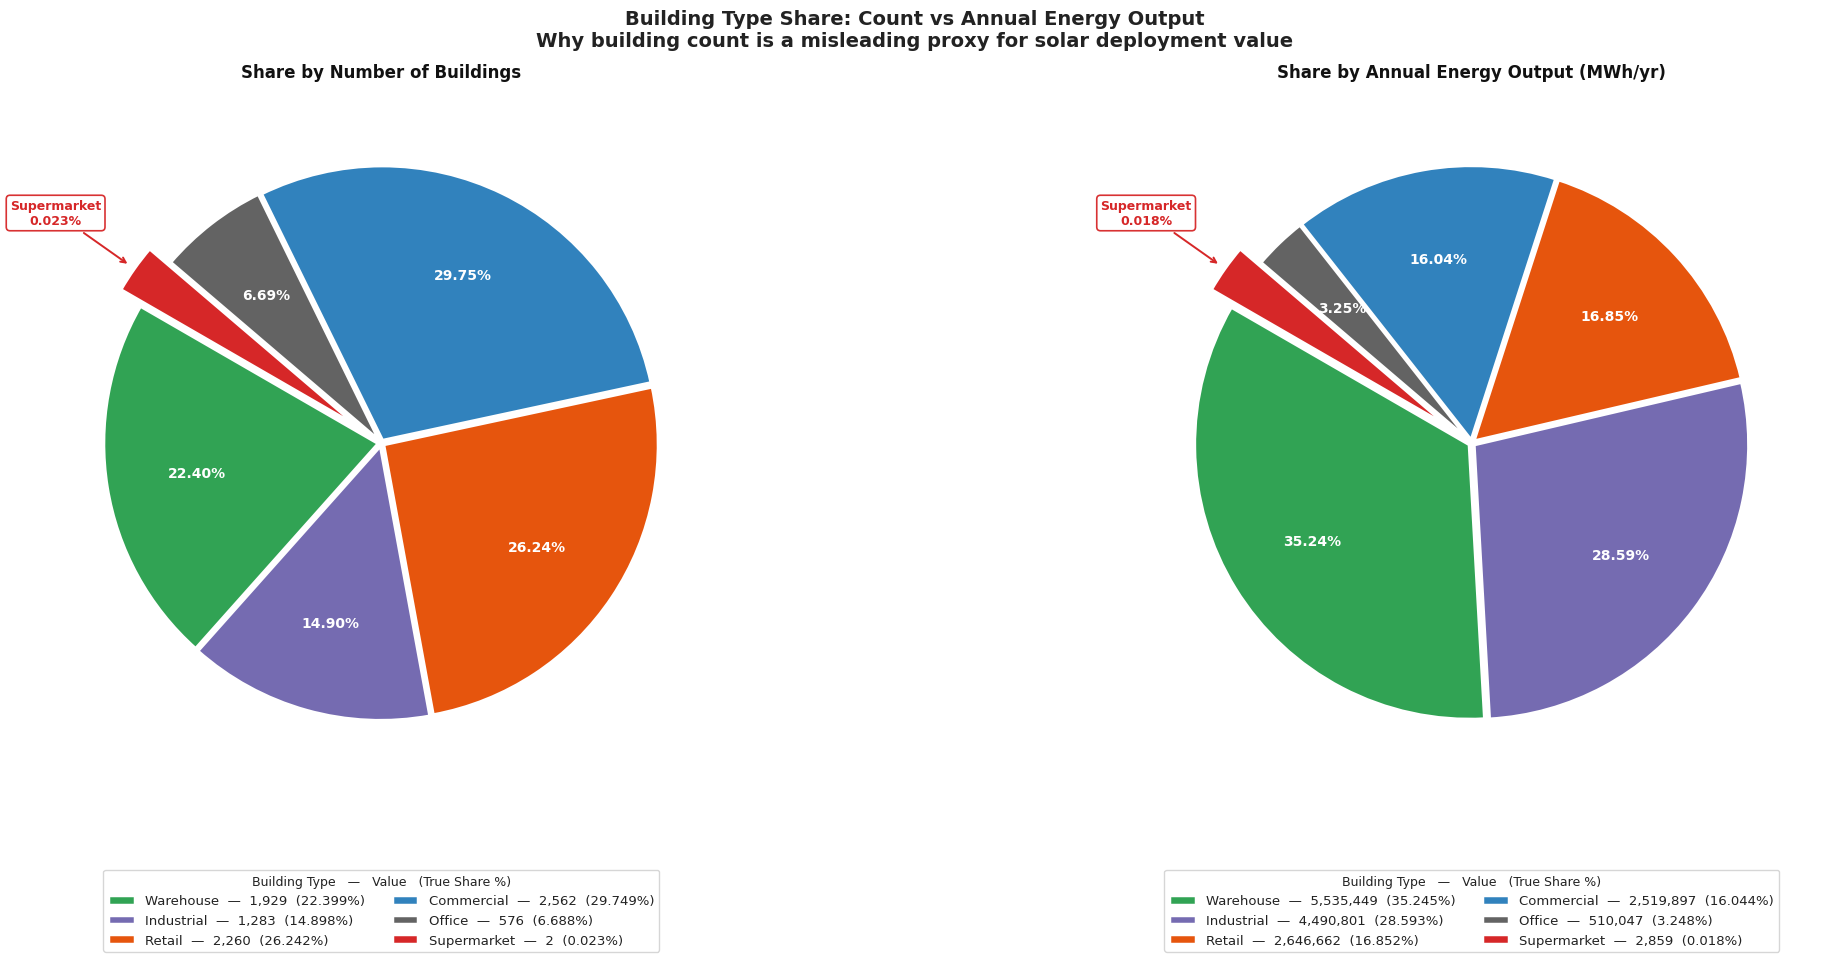

Saved: 02_building_type_pie.png


In [ ]:
# ── Pie chart — building type share ─────────────────────────────────────────
bt_pie = df.groupby('building').agg(
    Count     = ('name','count'),
    Total_MWh = ('Annual_MWh','sum'),
).sort_values('Total_MWh', ascending=False)

wedge_c = [BLDG.get(b,'#888') for b in bt_pie.index]

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Building Type Share: Count vs Annual Energy Output\n'
             'Why building count is a misleading proxy for solar deployment value',
             fontsize=14, fontweight='bold')

for ax, col, title in [
    (axes[0], bt_pie['Count'],     'Share by Number of Buildings'),
    (axes[1], bt_pie['Total_MWh'], 'Share by Annual Energy Output (MWh/yr)'),
]:
    # ── Give supermarket a guaranteed visible slice ──────────────────────────
    # Boost to 3% of total for rendering only; real % shown in labels & legend
    display_vals = col.copy().astype(float)
    floor_pct    = 0.03   # 3% minimum visual slice
    floor_abs    = display_vals.sum() * floor_pct
    display_vals['supermarket'] = max(float(display_vals['supermarket']), floor_abs)

    explode = [0.10 if b == 'supermarket' else 0.01 for b in bt_pie.index]

    wedges, _ = ax.pie(
        display_vals,
        labels=None,
        colors=wedge_c,
        startangle=150,
        explode=explode,
        wedgeprops={'edgecolor':'white','linewidth':2.5},
        autopct=None,
    )

    # ── Draw labels: large slices get internal label, small get external ─────
    real_pcts = col / col.sum() * 100
    for wedge, (btype, real_pct) in zip(wedges, real_pcts.items()):
        angle  = (wedge.theta2 + wedge.theta1) / 2
        cos_a  = np.cos(np.radians(angle))
        sin_a  = np.sin(np.radians(angle))
        label  = f'{real_pct:.3f}%' if real_pct < 1 else f'{real_pct:.2f}%'

        if btype == 'supermarket':
            # External label with leader line — clear and outside the pie
            x_out, y_out = cos_a * 1.45, sin_a * 1.45
            x_tip, y_tip = cos_a * 1.12, sin_a * 1.12
            ax.annotate(
                f'Supermarket\n{label}',
                xy=(x_tip, y_tip),
                xytext=(x_out, y_out),
                fontsize=9, fontweight='bold', color='#d62728',
                ha='center', va='center',
                arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.4),
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d62728',
                          lw=1.2, alpha=0.95)
            )
        elif real_pct > 3:
            # Internal label for slices large enough to contain text
            x_in, y_in = cos_a * 0.68, sin_a * 0.68
            ax.text(x_in, y_in, label,
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')

    ax.set_title(title, fontweight='bold', fontsize=12, pad=16)

    # ── Legend with real absolute numbers ─────────────────────────────────────
    legend_labels = [
        f"{b.capitalize()}  —  {v:,.0f}  ({v/col.sum()*100:.3f}%)"
        for b, v in zip(bt_pie.index, col)
    ]
    ax.legend(wedges, legend_labels,
              loc='lower center', fontsize=9.5,
              bbox_to_anchor=(0.5, -0.25),
              frameon=True, ncol=2,
              title='Building Type   —   Value   (True Share %)',
              title_fontsize=9)

plt.tight_layout()
plt.savefig('02_building_type_pie.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 02_building_type_pie.png")

## Section 5 — County-Level Solar Analysis

**Why this analysis was done:**
Understanding which counties hold the most solar potential is essential for
grid infrastructure planning, municipal policy, and investment sequencing.
A statewide or national programme cannot treat all counties equally —
capital is limited and must be directed where returns are highest.

Three panels address three distinct planning questions:

- **Total energy** (Panel 1): Where is the largest aggregate opportunity?
  Dallas County alone contributes 51.7% of the entire portfolio's annual output.
  The top four counties account for 94.9%.

- **Building count** (Panel 2): Where is the largest addressable market?
  High count means more installation contracts, more permitting activity,
  and more need for local workforce development.

- **Installation cost** (Panel 3): What capital commitment does each county require?
  This is essential for investment sequencing — which counties can be activated
  with limited initial capital vs which require large upfront commitment.

All values to 3 decimal places to distinguish counties with similar magnitudes
(particularly the peripheral counties Hunt, Parker, Rockwall, Wise).

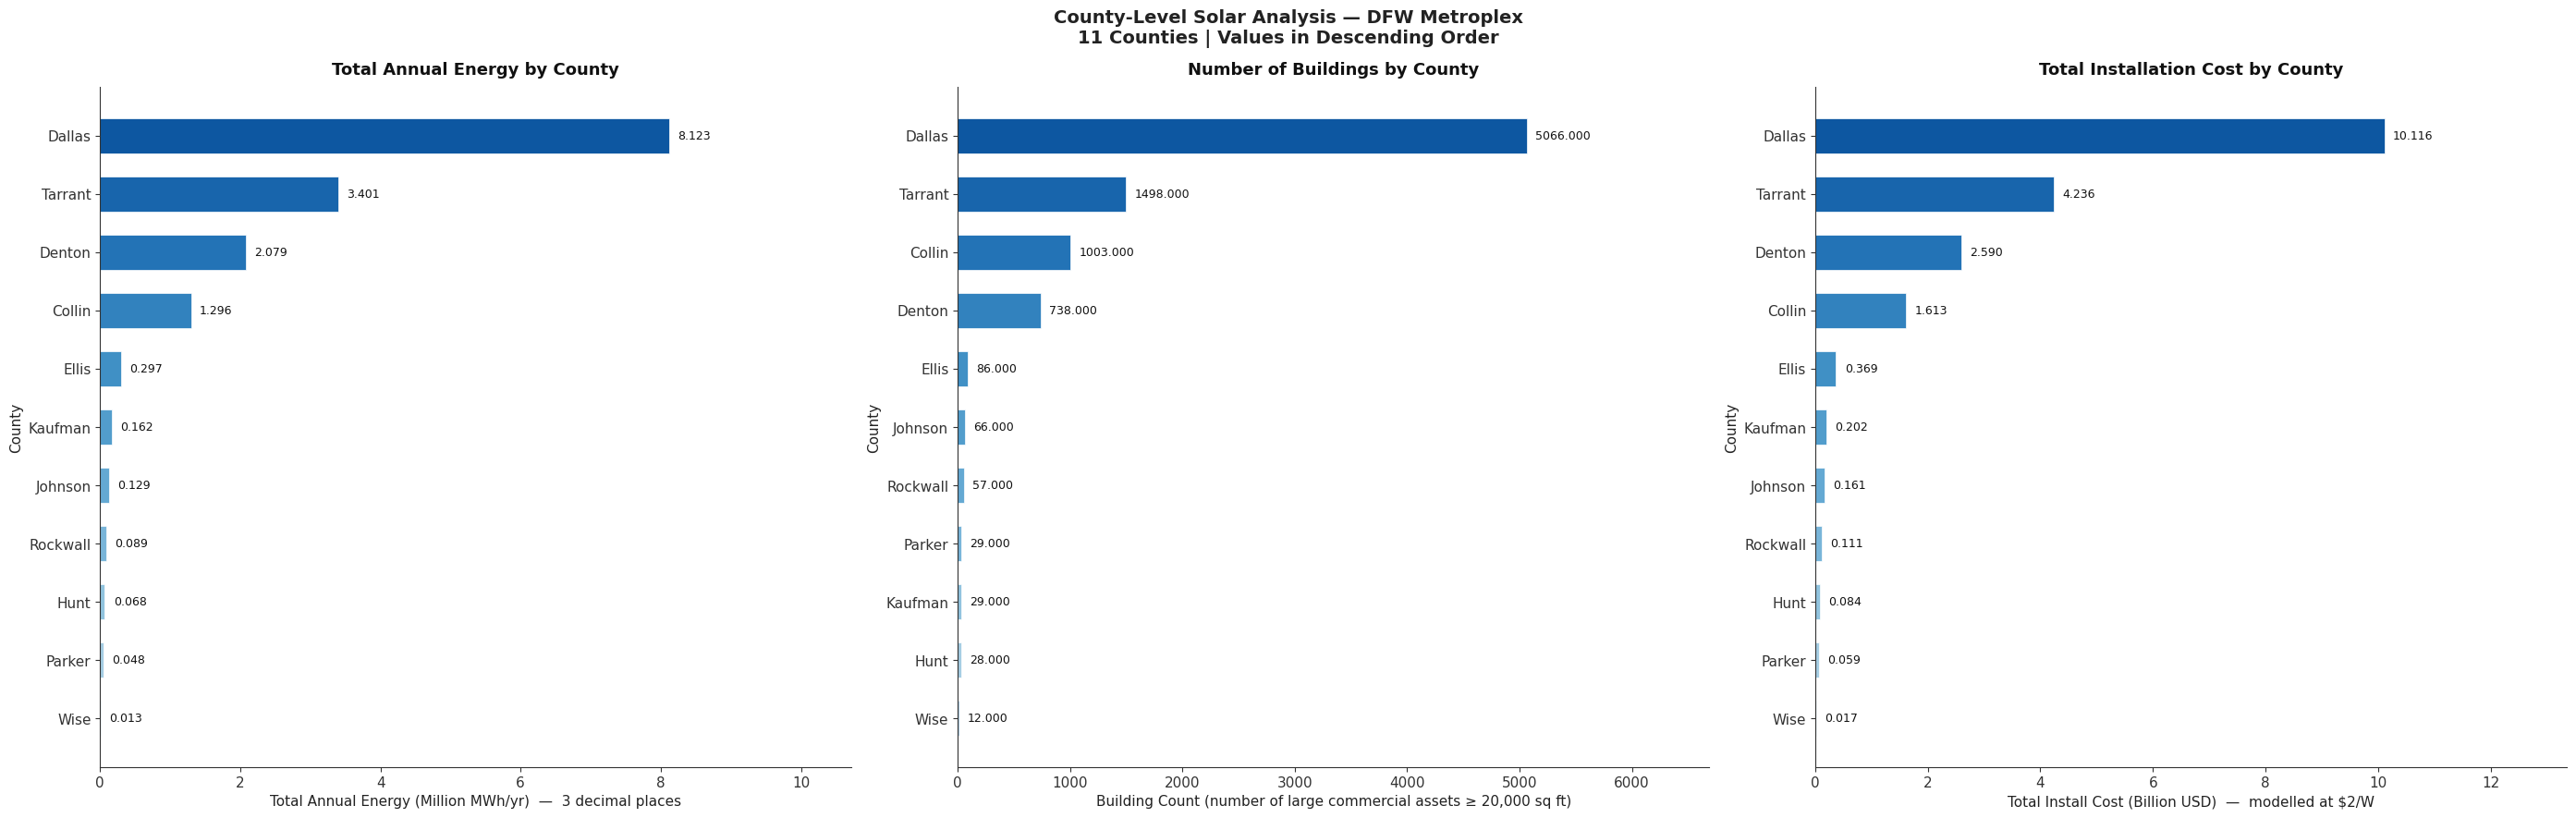

Saved: 03_county_analysis.png


In [ ]:
# ── County three-panel analysis ──────────────────────────────────────────────
cy = df.groupby('county_short').agg(
    Count        = ('name','count'),
    Total_MWh    = ('Annual_MWh','sum'),
    Total_CO2    = ('Carbon_Reduction_tonsCO2','sum'),
    Total_Cost_B = ('Estimated_Solar_Cost_USD','sum'),
).sort_values('Total_MWh', ascending=False)

panels_5 = [
    (cy['Total_MWh']/1e6,    'Total Annual Energy by County',
     'Total Annual Energy (Million MWh/yr)  —  3 decimal places'),
    (cy['Count'],             'Number of Buildings by County',
     'Building Count (number of large commercial assets ≥ 20,000 sq ft)'),
    (cy['Total_Cost_B']/1e9, 'Total Installation Cost by County',
     'Total Install Cost (Billion USD)  —  modelled at $2/W'),
]

fig, axes = plt.subplots(1, 3, figsize=(28, 9))
fig.suptitle('County-Level Solar Analysis — DFW Metroplex\n'
             '11 Counties | Values in Descending Order',
             fontsize=14, fontweight='bold')

for ax, (vals, title, xlabel) in zip(axes, panels_5):
    sorted_vals = vals.sort_values(ascending=True)
    n = len(sorted_vals)
    clrs = county_blues(n)[::-1]
    bars = ax.barh(sorted_vals.index, sorted_vals.values,
                   color=clrs, edgecolor='white', linewidth=0.5, height=0.6)
    for bar, val in zip(bars, sorted_vals.values):
        ax.text(bar.get_width() + sorted_vals.max() * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9, color='#111111')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('County')
    ax.set_xlim(0, sorted_vals.max() * 1.32)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('03_county_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 03_county_analysis.png")

## Section 6 — Solar Energy Concentration (Pareto Curve)

**Why this analysis was done:**
Not all buildings contribute equally to the solar portfolio — and the degree of
inequality has direct implications for deployment strategy. If energy potential
were uniformly distributed, every building would deserve equal attention.
If it is highly concentrated, a targeted programme focusing on the top percentile
of buildings would be far more efficient than a broad-based one.

This Pareto curve (also called a concentration or Lorenz curve) answers:
*"If I target the top N% of buildings by energy potential, what fraction of
the total available energy do I capture?"*

**Finding:** The top 10.3% of buildings (by individual annual energy output)
already deliver 50% of the entire portfolio's generation potential.
The top 40.4% of buildings deliver 80%.

This extreme concentration is driven by building footprint area — a small number
of very large industrial facilities and distribution warehouses have rooftops
5–10× larger than the median commercial building.
The implication for the paper: a first-wave deployment targeting the top decile
of buildings would capture half the total DFW rooftop solar potential
while requiring resources to assess only ~860 buildings out of 8,612.

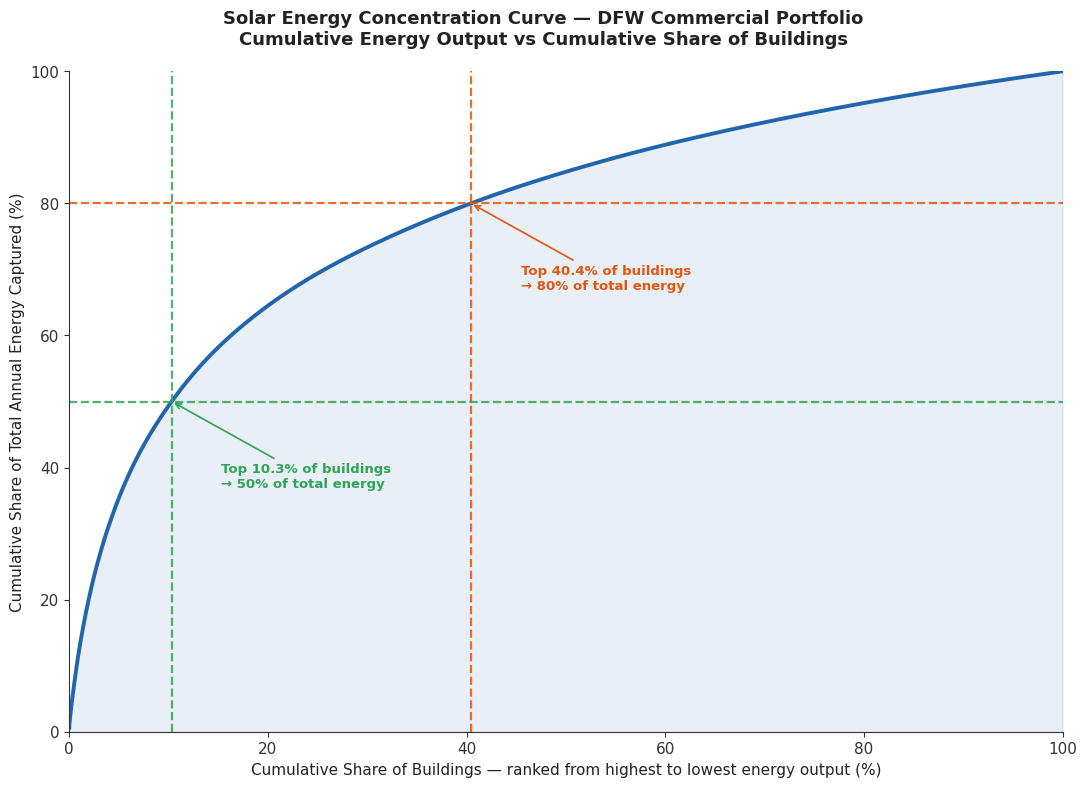

Saved: 05_pareto_energy.png


In [ ]:
# ── Pareto cumulative energy curve ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle('Solar Energy Concentration Curve — DFW Commercial Portfolio\n'
             'Cumulative Energy Output vs Cumulative Share of Buildings',
             fontsize=13, fontweight='bold')

smwh = df['Annual_MWh'].sort_values(ascending=False).reset_index(drop=True)
cum  = smwh.cumsum() / smwh.sum() * 100
bpct = np.arange(1, len(cum)+1) / len(cum) * 100

ax.plot(bpct, cum, color='#2166ac', lw=2.8)
ax.fill_between(bpct, cum, alpha=0.10, color='#2166ac')

for target, clr in [(80,'#e6550d'), (50,'#31a354')]:
    idx = int((cum >= target).idxmax())
    b   = (idx+1) / len(cum) * 100
    ax.axhline(target, color=clr, lw=1.6, ls='--', alpha=0.85)
    ax.axvline(b,      color=clr, lw=1.6, ls='--', alpha=0.85)
    ax.annotate(
        f'Top {b:.1f}% of buildings\n→ {target}% of total energy',
        xy=(b, target), xytext=(b + 5, target - 13),
        fontsize=9.5, color=clr, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=clr, lw=1.2)
    )

ax.set_xlabel('Cumulative Share of Buildings — ranked from highest to lowest energy output (%)',
              fontsize=11)
ax.set_ylabel('Cumulative Share of Total Annual Energy Captured (%)', fontsize=11)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('05_pareto_energy.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 05_pareto_energy.png")

## Section 7 — Building Size Distribution

**Why this analysis was done:**
In the photovoltaic output model used in this paper (*E = A × r × H × PR*),
building footprint area is the primary input variable — all other parameters
are held constant across the portfolio. Understanding how footprint area
is distributed across the 8,612 buildings therefore directly explains
the shape of the energy output distribution.

This chart groups buildings into six size brackets and shows how many buildings
fall into each. The colour intensity is graduated: the tallest bar (most buildings)
receives the darkest shade, lighter shades indicate smaller counts.

**Finding:** The majority of buildings (79.3% — 6,829 out of 8,612) sit in the 20K–100K sq ft range —
moderately large commercial and retail properties. Only a small fraction exceed
500,000 sq ft, but those large industrial and warehouse buildings are responsible
for a disproportionate share of total energy output, as shown in the Pareto curve.

**Why useful for the paper:** This size distribution explains why the energy
output distribution is right-skewed and why a size-threshold criterion
(e.g., targeting only buildings above 100K sq ft) would dramatically reduce
assessment effort while retaining most of the energy potential.

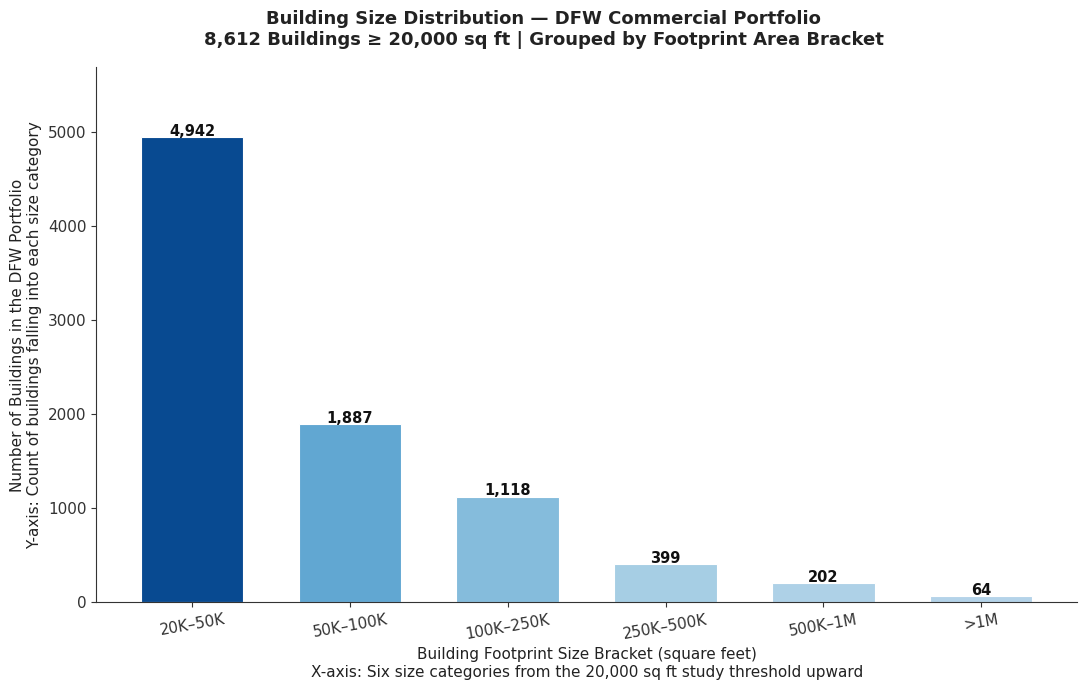

Saved: 06_building_size_dist.png


In [ ]:
# ── Building size distribution — bracket bar chart ───────────────────────────
bins_e   = [20000, 50000, 100000, 250000, 500000, 1000000, df['Building_Sq_Ft'].max()+1]
labels_b = ['20K–50K', '50K–100K', '100K–250K', '250K–500K', '500K–1M', '>1M']
cnts     = [((df['Building_Sq_Ft'] >= bins_e[i]) &
             (df['Building_Sq_Ft'] <  bins_e[i+1])).sum()
            for i in range(len(labels_b))]

# Sort descending by count
pairs     = sorted(zip(cnts, labels_b), reverse=True)
cnts_s, labels_s = zip(*pairs)
norm_vals = np.array(cnts_s, dtype=float) / max(cnts_s)
clrs_size = [mcolors.to_hex(c) for c in plt.cm.Blues(0.30 + 0.60 * norm_vals)]

fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle('Building Size Distribution — DFW Commercial Portfolio\n'
             '8,612 Buildings ≥ 20,000 sq ft | Grouped by Footprint Area Bracket',
             fontsize=13, fontweight='bold')

bars = ax.bar(range(len(labels_s)), cnts_s,
              color=clrs_size, edgecolor='white', linewidth=0.8, width=0.65)
for bar, val in zip(bars, cnts_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 18,
            f'{val:,}', ha='center', fontsize=10.5, color='#111111', fontweight='bold')

ax.set_xticks(range(len(labels_s)))
ax.set_xticklabels(labels_s, fontsize=11, rotation=10)
ax.set_xlabel('Building Footprint Size Bracket (square feet)\n'
              'X-axis: Six size categories from the 20,000 sq ft study threshold upward',
              fontsize=11)
ax.set_ylabel('Number of Buildings in the DFW Portfolio\n'
              'Y-axis: Count of buildings falling into each size category',
              fontsize=11)
ax.set_ylim(0, max(cnts_s) * 1.15)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('06_building_size_dist.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 06_building_size_dist.png")

## Section 8 — Carbon Emission Reduction Analysis

**Why this analysis was done:**
Solar energy is ultimately deployed to reduce carbon emissions.
The energy output numbers in the previous sections need to be translated
into the metric that climate policy, ESG reporting, and carbon credit markets
use: metric tons of CO₂ avoided per year.

Using the ERCOT grid emission factor of 0.386 kg CO₂ per kWh
(the average carbon intensity of the Texas electricity grid),
each MWh of solar generation avoids a specific and auditable quantity of CO₂
that would otherwise have been emitted by the gas and coal plants displaced.

Two panels are shown:

**By Building Type:** Warehouse buildings avoid the most CO₂ in aggregate (1.854 million
metric tons/yr) because they generate the most energy. But the CO₂ per square foot
metric is identical across types — confirming the model's consistency.

**By County:** Dallas County's avoided CO₂ (2.721 million metric tons/yr) exceeds
the total annual CO₂ output of most mid-sized US cities. This provides a
compelling climate case for county-level solar incentive programmes
that complements the energy economics argument.

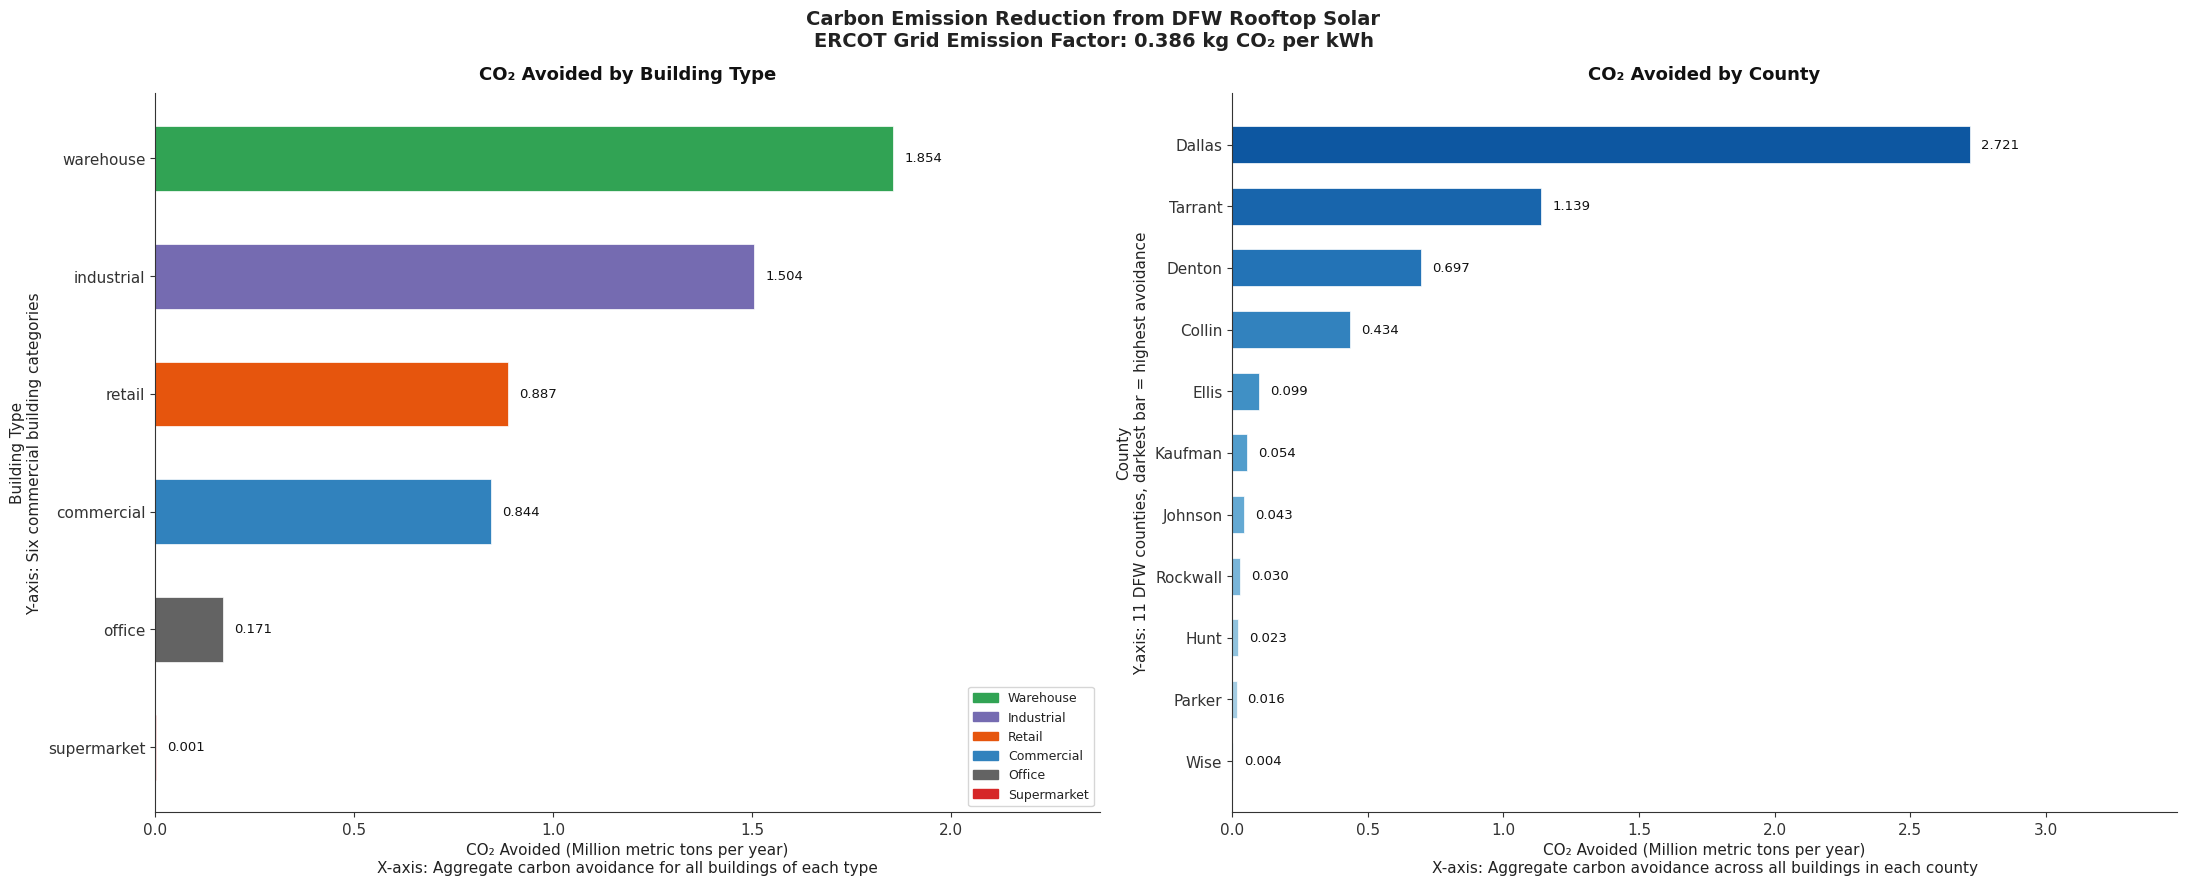

Saved: 07_carbon_analysis.png


In [ ]:
# ── Carbon reduction — by type and by county ─────────────────────────────────
co2_t = df.groupby('building')['Carbon_Reduction_tonsCO2'].sum().sort_values(ascending=False)
co2_c = df.groupby('county_short')['Carbon_Reduction_tonsCO2'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Carbon Emission Reduction from DFW Rooftop Solar\n'
             'ERCOT Grid Emission Factor: 0.386 kg CO₂ per kWh',
             fontsize=14, fontweight='bold')

# ── By building type ──────────────────────────────────────────────────────────
ax = axes[0]
sv = co2_t.sort_values(ascending=True)
bars = ax.barh(sv.index, sv/1e6,
               color=[BLDG.get(b,'#888') for b in sv.index],
               edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars, sv):
    ax.text(bar.get_width() + sv.max()/1e6 * 0.015,
            bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.3f}', va='center', fontsize=9.5, color='#111111')
ax.set_title('CO₂ Avoided by Building Type', fontweight='bold', pad=10)
ax.set_xlabel('CO₂ Avoided (Million metric tons per year)\n'
              'X-axis: Aggregate carbon avoidance for all buildings of each type')
ax.set_ylabel('Building Type\nY-axis: Six commercial building categories')
ax.set_xlim(0, sv.max()/1e6 * 1.28)
ax.spines[['top','right']].set_visible(False)
patches = [mpatches.Patch(color=BLDG.get(b,'#888'), label=b.capitalize()) for b in co2_t.index]
ax.legend(handles=patches, fontsize=9, loc='lower right')

# ── By county ─────────────────────────────────────────────────────────────────
ax = axes[1]
sv2 = co2_c.sort_values(ascending=True)
n = len(sv2)
clrs = county_blues(n)[::-1]
bars = ax.barh(sv2.index, sv2/1e6, color=clrs, edgecolor='white', linewidth=0.5, height=0.6)
for bar, val in zip(bars, sv2):
    ax.text(bar.get_width() + sv2.max()/1e6 * 0.015,
            bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.3f}', va='center', fontsize=9.5, color='#111111')
ax.set_title('CO₂ Avoided by County', fontweight='bold', pad=10)
ax.set_xlabel('CO₂ Avoided (Million metric tons per year)\n'
              'X-axis: Aggregate carbon avoidance across all buildings in each county')
ax.set_ylabel('County\nY-axis: 11 DFW counties, darkest bar = highest avoidance')
ax.set_xlim(0, sv2.max()/1e6 * 1.28)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('07_carbon_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 07_carbon_analysis.png")

## Section 9 — Solar Installation Cost Analysis

**Why this analysis was done:**
Energy potential alone does not determine deployment feasibility —
cost does. This section quantifies the capital required to realise the
DFW rooftop solar opportunity, using the NREL benchmark of $2.00/W DC
installed for commercial-scale rooftop PV systems.

Two panels address two different investment planning questions:

**By Building Type (Panel 2):** Which categories require the most total capital?
Warehouse buildings require the highest aggregate investment ($6.89B) because they
have the largest systems — but they also deliver the highest energy return.
This panel, read alongside the energy panel, confirms that all building types
have an identical cost-per-MWh ratio under the uniform-rate assumption,
validating the model's internal consistency.

**By Cost Bracket (Panel 4):** How many buildings fall into each financing tier?
This is critical for financial planners: which financing instruments
(C-PACE, Power Purchase Agreements, utility incentives) are appropriate for
which portion of the portfolio? Buildings in the $1M–$5M range represent the
core of standard commercial solar financing. Buildings above $25M are the
large industrial outliers that require institutional or utility-scale financing.

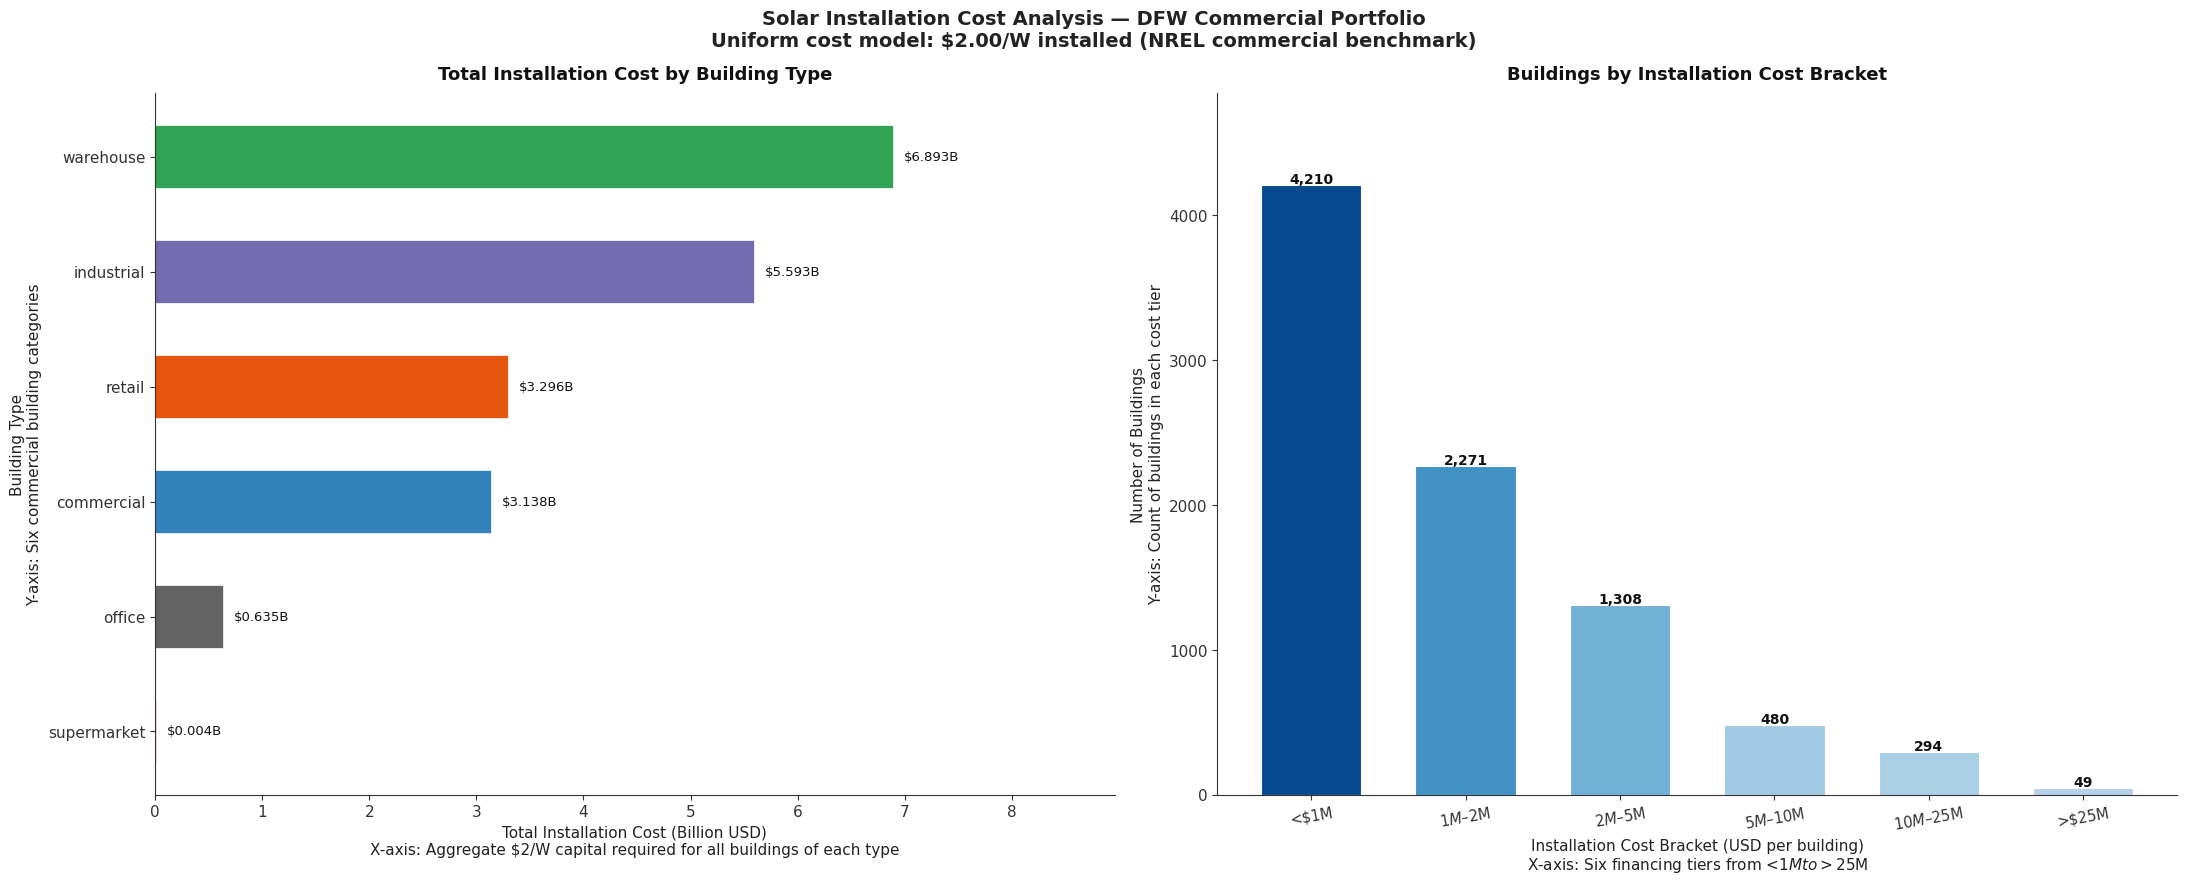

Saved: 08_cost_analysis.png


In [ ]:
# ── Installation cost — by type and by cost bracket ─────────────────────────
cost_t = df.groupby('building')['Estimated_Solar_Cost_Million_USD'].sum().sort_values(ascending=False)

ce     = [0, 1, 2, 5, 10, 25, df['Estimated_Solar_Cost_Million_USD'].max()+1]
cl     = ['<$1M','$1M–$2M','$2M–$5M','$5M–$10M','$10M–$25M','>$25M']
cc_raw = [((df['Estimated_Solar_Cost_Million_USD']>=ce[i]) &
           (df['Estimated_Solar_Cost_Million_USD']< ce[i+1])).sum()
          for i in range(len(cl))]

# Sort cost brackets descending by count
pairs2    = sorted(zip(cc_raw, cl), reverse=True)
cc_s, cl_s = zip(*pairs2)
norm_cc   = np.array(cc_s, dtype=float) / max(cc_s)
clrs_cc   = [mcolors.to_hex(c) for c in plt.cm.Blues(0.30 + 0.60*norm_cc)]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Solar Installation Cost Analysis — DFW Commercial Portfolio\n'
             'Uniform cost model: $2.00/W installed (NREL commercial benchmark)',
             fontsize=14, fontweight='bold')

# ── By building type ──────────────────────────────────────────────────────────
ax = axes[0]
sv = cost_t.sort_values(ascending=True)
bars = ax.barh(sv.index, sv/1000, color=[BLDG.get(b,'#888') for b in sv.index],
               edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars, sv):
    ax.text(bar.get_width() + sv.max()/1000 * 0.015,
            bar.get_y() + bar.get_height()/2,
            f'${val/1000:.3f}B', va='center', fontsize=9.5, color='#111111')
ax.set_title('Total Installation Cost by Building Type', fontweight='bold', pad=10)
ax.set_xlabel('Total Installation Cost (Billion USD)\n'
              'X-axis: Aggregate $2/W capital required for all buildings of each type')
ax.set_ylabel('Building Type\nY-axis: Six commercial building categories')
ax.set_xlim(0, sv.max()/1000 * 1.30)
ax.spines[['top','right']].set_visible(False)

# ── By cost bracket ───────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(range(len(cl_s)), cc_s,
              color=clrs_cc, edgecolor='white', linewidth=0.8, width=0.65)
for bar, val in zip(bars, cc_s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=10, color='#111111', fontweight='bold')
ax.set_xticks(range(len(cl_s)))
ax.set_xticklabels(cl_s, fontsize=10.5, rotation=10)
ax.set_title('Buildings by Installation Cost Bracket', fontweight='bold', pad=10)
ax.set_xlabel('Installation Cost Bracket (USD per building)\n'
              'X-axis: Six financing tiers from <$1M to >$25M',
              fontsize=11)
ax.set_ylabel('Number of Buildings\n'
              'Y-axis: Count of buildings in each cost tier',
              fontsize=11)
ax.set_ylim(0, max(cc_s) * 1.15)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('08_cost_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 08_cost_analysis.png")

## Section 10 — Household Impact Analysis

**Why this analysis was done:**
Generating electricity is only part of the story. The social value of rooftop solar
depends on whether the energy is generated *near* the communities that need it.
A large industrial building on an empty exurban lot may generate enormous solar energy
but serves almost no nearby residents. A smaller office building in a dense urban
neighbourhood may generate less energy but delivers it directly to thousands of households.

This scatter chart plots every building simultaneously on two dimensions:
- **X-axis:** Number of residential households within 1 mile (demand-side proximity)
- **Y-axis:** Annual solar energy generation capacity (supply-side output)
- **Colour:** CO₂ avoided per building (darker orange/red = more CO₂ avoided)

The dashed lines mark portfolio medians on both axes, dividing the space into four quadrants.
Buildings in the **upper-right quadrant** — high energy AND high household proximity —
are the most valuable deployment targets: they generate large amounts of clean energy
close to where people live.

**Core finding visible in this chart:** There is a negative spatial correlation between
generation capacity and household proximity (r = −0.19). Large-footprint buildings
(industrial, warehouse) cluster in the lower-right: high energy, few nearby households.
Small commercial buildings in dense urban areas cluster in the upper-left: many households,
moderate energy. This spatial tension is the central analytical finding of the paper
and is made visible here.

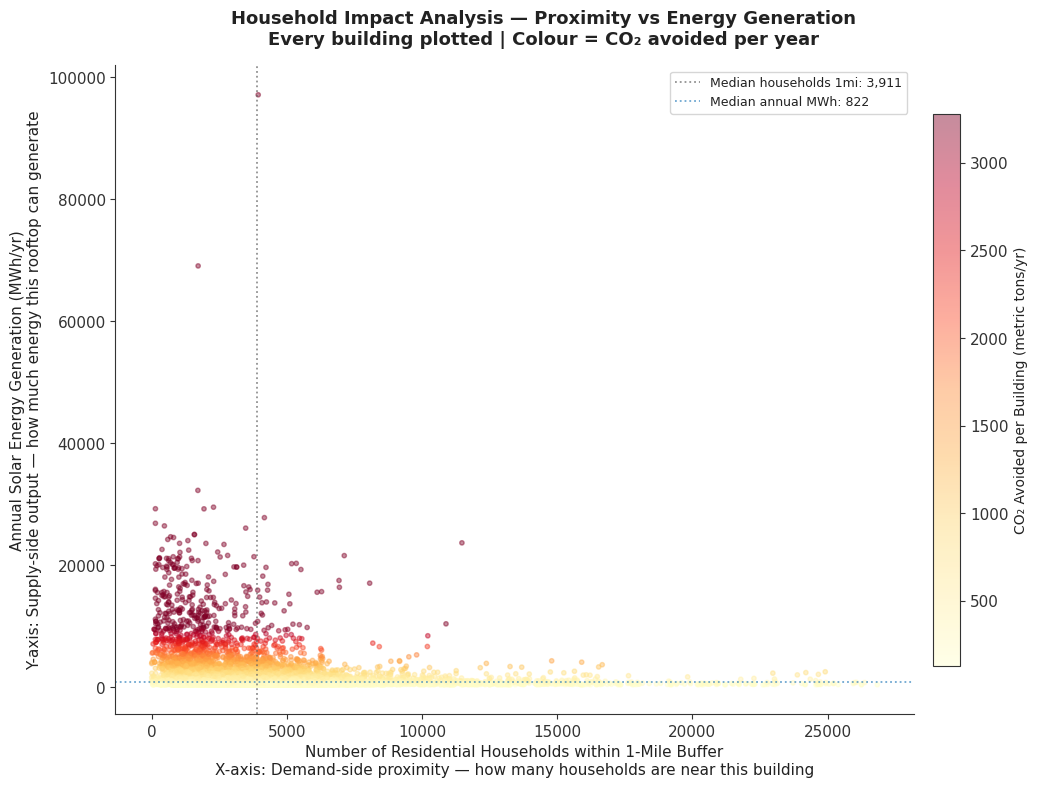

Saved: 09_household_scatter.png


In [ ]:
# ── Household impact scatter ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
fig.suptitle('Household Impact Analysis — Proximity vs Energy Generation\n'
             'Every building plotted | Colour = CO₂ avoided per year',
             fontsize=13, fontweight='bold')

sc = ax.scatter(
    df['Households_1mi'], df['Annual_MWh'],
    c=df['Carbon_Reduction_tonsCO2'],
    cmap='YlOrRd', alpha=0.45, s=10,
    vmax=df['Carbon_Reduction_tonsCO2'].quantile(0.97)
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('CO₂ Avoided per Building (metric tons/yr)', fontsize=10)

med_hh  = df['Households_1mi'].median()
med_mwh = df['Annual_MWh'].median()
ax.axvline(med_hh,  color='#636363', lw=1.3, ls=':', alpha=0.7,
           label=f'Median households 1mi: {med_hh:,.0f}')
ax.axhline(med_mwh, color='#3182bd', lw=1.3, ls=':', alpha=0.7,
           label=f'Median annual MWh: {med_mwh:,.0f}')

ax.set_xlabel('Number of Residential Households within 1-Mile Buffer\n'
              'X-axis: Demand-side proximity — how many households are near this building',
              fontsize=11)
ax.set_ylabel('Annual Solar Energy Generation (MWh/yr)\n'
              'Y-axis: Supply-side output — how much energy this rooftop can generate',
              fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('09_household_scatter.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 09_household_scatter.png")

## Section 11 — EV Charging Station Proximity Analysis

**Why this analysis was done:**
Rooftop solar and EV charging are complementary technologies.
A commercial building that generates solar energy on its roof and has EV chargers
in its parking lot can supply those chargers directly — reducing grid dependency,
peak demand charges, and the carbon intensity of every vehicle charged there.
This creates a compound decarbonisation benefit: clean power generation
*and* clean transportation, from a single rooftop investment.

This chart quantifies the EV co-location opportunity in the DFW portfolio.
The X-axis shows the number of existing EV charging stations within 1 mile of each building.
The Y-axis shows how many of the 8,612 buildings have that many stations nearby.

**Key finding:** 2,609 buildings (30.3% of the portfolio) currently have zero EV stations
within 1 mile. These buildings represent a dual opportunity: installing rooftop solar
AND adding new EV chargers powered by that solar would deliver two infrastructure
upgrades in a single investment — making them eligible for combined solar+EV incentives.

Buildings with 10+ existing EV stations nearby already sit within established charging
corridors. Adding rooftop solar to those buildings would maximise the utilisation
of existing EV infrastructure by providing a local clean supply source.

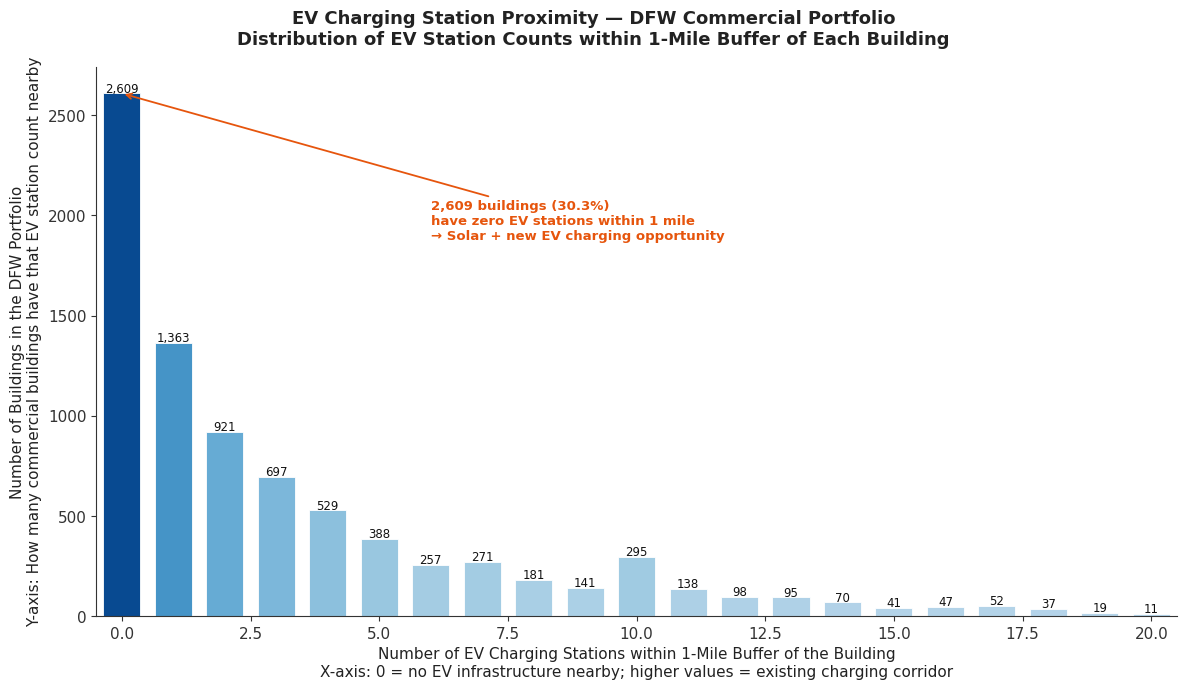

Saved: 10_ev_analysis.png


In [ ]:
# ── EV station proximity — within 1 mile ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('EV Charging Station Proximity — DFW Commercial Portfolio\n'
             'Distribution of EV Station Counts within 1-Mile Buffer of Each Building',
             fontsize=13, fontweight='bold')

ev1 = df['EV_Stations_1mi'].value_counts().sort_index()
ev1 = ev1[ev1.index <= 20]

zero_count = (df['EV_Stations_1mi'] == 0).sum()
zero_pct   = zero_count / len(df) * 100

norm_ev = ev1.values / ev1.values.max()
clrs_ev = [mcolors.to_hex(c) for c in plt.cm.Blues(0.30 + 0.60*norm_ev)]

bars = ax.bar(ev1.index, ev1.values, color=clrs_ev, edgecolor='white', linewidth=0.6, width=0.72)
for bar, val in zip(bars, ev1.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 6,
            f'{val:,}', ha='center', fontsize=8.5, color='#111111')

ax.annotate(
    f'{zero_count:,} buildings ({zero_pct:.1f}%)\nhave zero EV stations within 1 mile\n'
    f'→ Solar + new EV charging opportunity',
    xy=(0, ev1[0]), xytext=(6, ev1.max() * 0.72),
    fontsize=9.5, color='#e6550d', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#e6550d', lw=1.3)
)

ax.set_xlabel('Number of EV Charging Stations within 1-Mile Buffer of the Building\n'
              'X-axis: 0 = no EV infrastructure nearby; higher values = existing charging corridor',
              fontsize=11)
ax.set_ylabel('Number of Buildings in the DFW Portfolio\n'
              'Y-axis: How many commercial buildings have that EV station count nearby',
              fontsize=11)
ax.set_xlim(-0.5, 20.5)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('10_ev_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 10_ev_analysis.png")

## Section 13 — Pearson Correlation Analysis

**Why this analysis was done:**
The paper makes a spatial argument: that generation capacity and residential proximity
are negatively correlated — meaning that buildings capable of generating the most solar
energy are *not* located near the most households, and vice versa.
Pearson correlation quantifies the strength of that relationship with a single number,
making the argument mathematically verifiable and reproducible.

Pearson r measures the linear relationship between two continuous variables,
ranging from −1 (perfect negative relationship) to +1 (perfect positive), 0 = none.
It is the appropriate measure here because both variables are continuous and
the relationship of interest is linear.

**Critical methodological note:**
Annual MWh, installation cost, CO₂, and households powered are all derived from
building footprint area using the same formula. Including them would produce
trivial r = 1.000 correlations that carry no information and would inflate
the apparent complexity of the correlation structure. Only the seven truly
independent variables are included.

**Key findings:**
- Building size is *negatively* correlated with household proximity (r ≈ −0.19 to −0.23):
  larger buildings are in less-dense residential areas — the spatial tension finding.
- Households within 1 mile and 3 miles are strongly correlated with each other (r ≈ 0.74):
  buildings in dense 1-mile catchments also sit in dense 3-mile catchments.
- EV station counts correlate with household density (r ≈ 0.54): EV infrastructure
  has been deployed where people live, not where industrial buildings are.

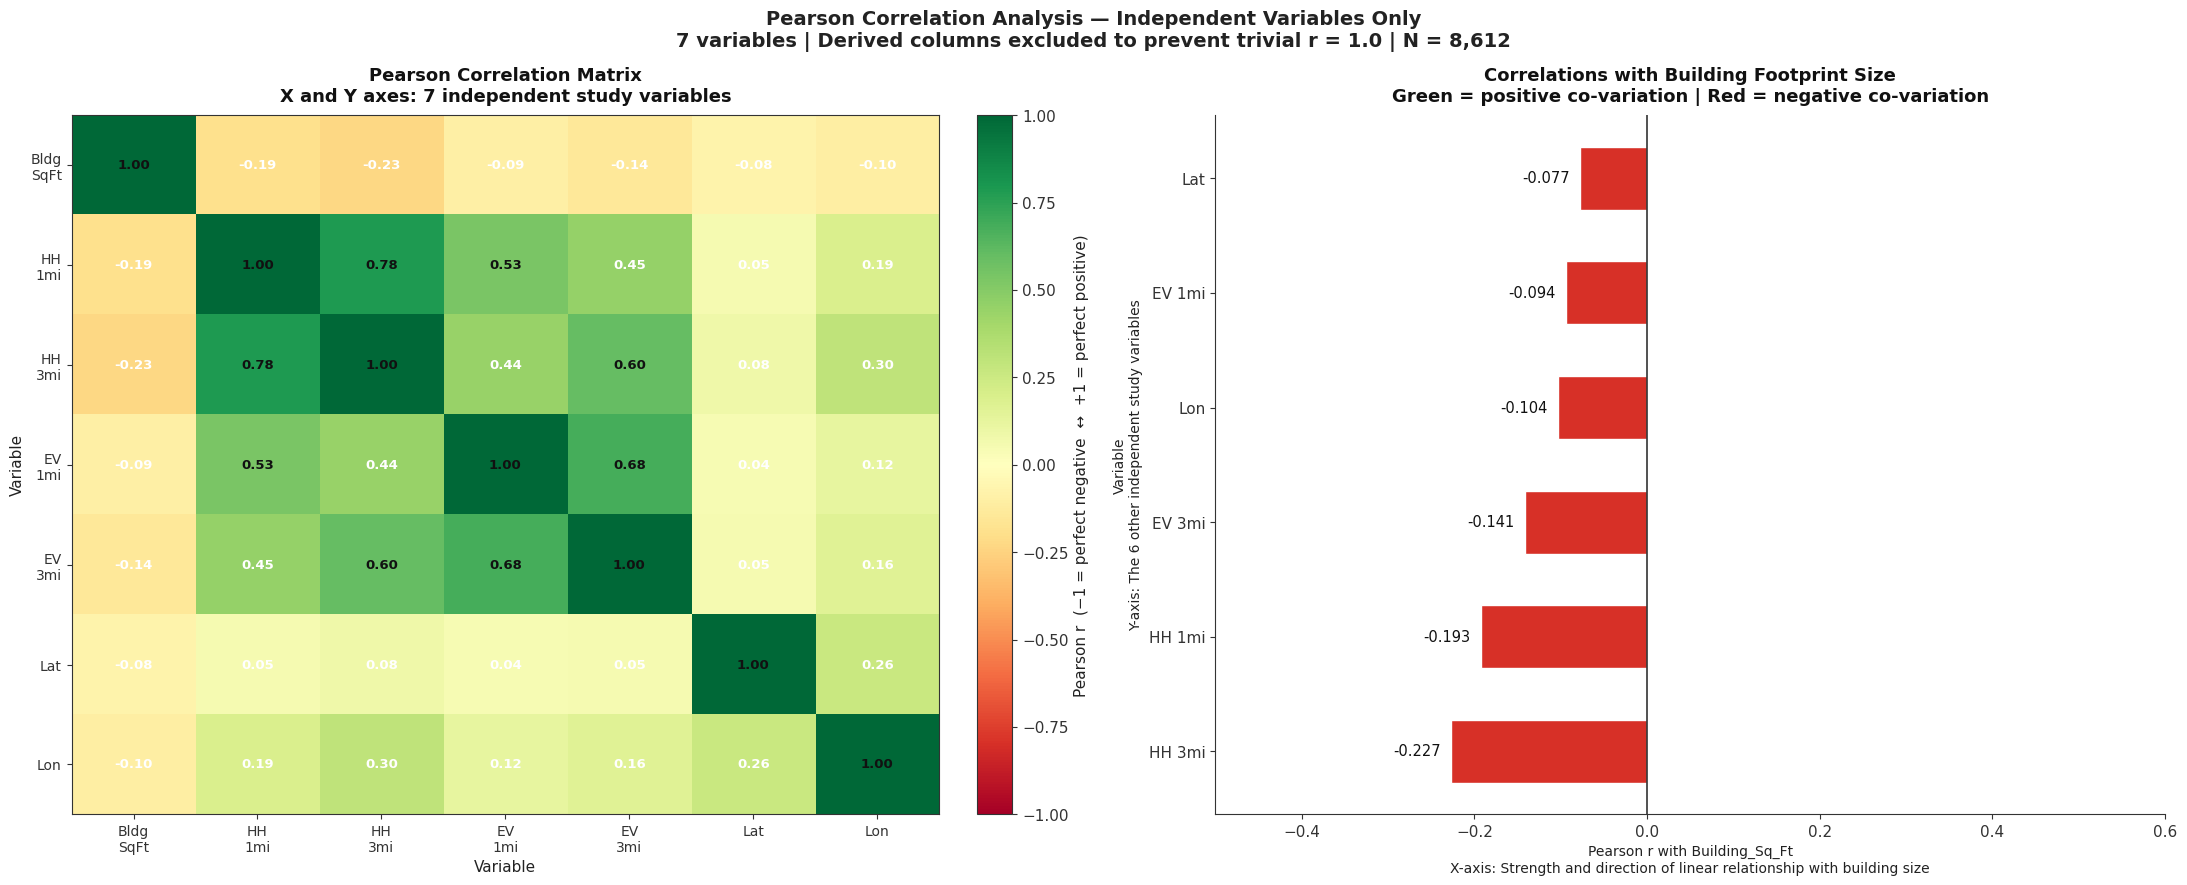

Saved: 12_pearson_correlation.png


In [ ]:
# ── Pearson correlation — independent variables only ─────────────────────────
independent_cols = ['Building_Sq_Ft','Households_1mi','Households_3mi',
                    'EV_Stations_1mi','EV_Stations_3mi','latitude','longitude']
short_lbl        = ['Bldg\nSqFt','HH\n1mi','HH\n3mi','EV\n1mi','EV\n3mi','Lat','Lon']
corr             = df[independent_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Pearson Correlation Analysis — Independent Variables Only\n'
             '7 variables | Derived columns excluded to prevent trivial r = 1.0 | N = 8,612',
             fontsize=14, fontweight='bold')

# ── Heatmap ───────────────────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(short_lbl))); ax.set_xticklabels(short_lbl, fontsize=10)
ax.set_yticks(range(len(short_lbl))); ax.set_yticklabels(short_lbl, fontsize=10)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i,j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9.5,
                color='#111111' if abs(v) > 0.5 else 'white', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
             label='Pearson r  (−1 = perfect negative  ↔  +1 = perfect positive)')
ax.set_title('Pearson Correlation Matrix\n'
             'X and Y axes: 7 independent study variables',
             fontweight='bold', pad=10)
ax.set_xlabel('Variable', fontsize=11)
ax.set_ylabel('Variable', fontsize=11)

# ── Bar chart — correlations with building size ────────────────────────────────
ax = axes[1]
pc  = corr['Building_Sq_Ft'].drop('Building_Sq_Ft').sort_values()
lm  = dict(zip(independent_cols, short_lbl))
yl  = [lm.get(c,c).replace('\n',' ') for c in pc.index]
bar_colors = ['#d73027' if v < 0 else '#1a9850' for v in pc.values]
bars = ax.barh(yl, pc.values, color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, pc.values):
    xpos = bar.get_width() + 0.012 if val >= 0 else bar.get_width() - 0.012
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=10.5, color='#111111',
            ha='left' if val >= 0 else 'right')
ax.axvline(0, color='#333333', lw=1.2)
ax.set_title('Correlations with Building Footprint Size\n'
             'Green = positive co-variation | Red = negative co-variation',
             fontweight='bold', pad=10)
ax.set_xlabel('Pearson r with Building_Sq_Ft\n'
              'X-axis: Strength and direction of linear relationship with building size',
              fontsize=10)
ax.set_ylabel('Variable\nY-axis: The 6 other independent study variables', fontsize=10)
ax.set_xlim(-0.5, 0.6)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('12_pearson_correlation.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 12_pearson_correlation.png")

## Section 15 — Estimated Monthly Solar Output

**Why this analysis was done:**
The annual energy figures presented throughout the paper are averages.
But solar output is seasonal — it peaks in summer and drops in winter —
and that seasonality matters for grid integration planning and for
understanding when the DFW solar portfolio delivers its greatest value.

Texas grid stress also peaks in summer (air conditioning demand from June to August).
If DFW rooftop solar peaks in the same months, it delivers its energy at exactly
the moment the grid needs it most — a temporal alignment that substantially increases
the system value of this distributed resource beyond its raw kWh output.

This chart uses NREL NSRDB monthly peak sun hours for DFW
(ranging from 3.9 hrs/day in December to 6.5 hrs/day in June)
to scale the fleet's daily output across each month.

**Panel 1** shows total fleet output by month in billion kWh.
June is the peak month; December is the trough.
The orange dashed line marks the simple monthly average — summer months exceed it
by ~18% and winter months fall ~25% below it.

**Panel 2** overlays NREL's peak sun hours on the bar chart using a dual axis,
confirming that the model's output tracks irradiance as expected.

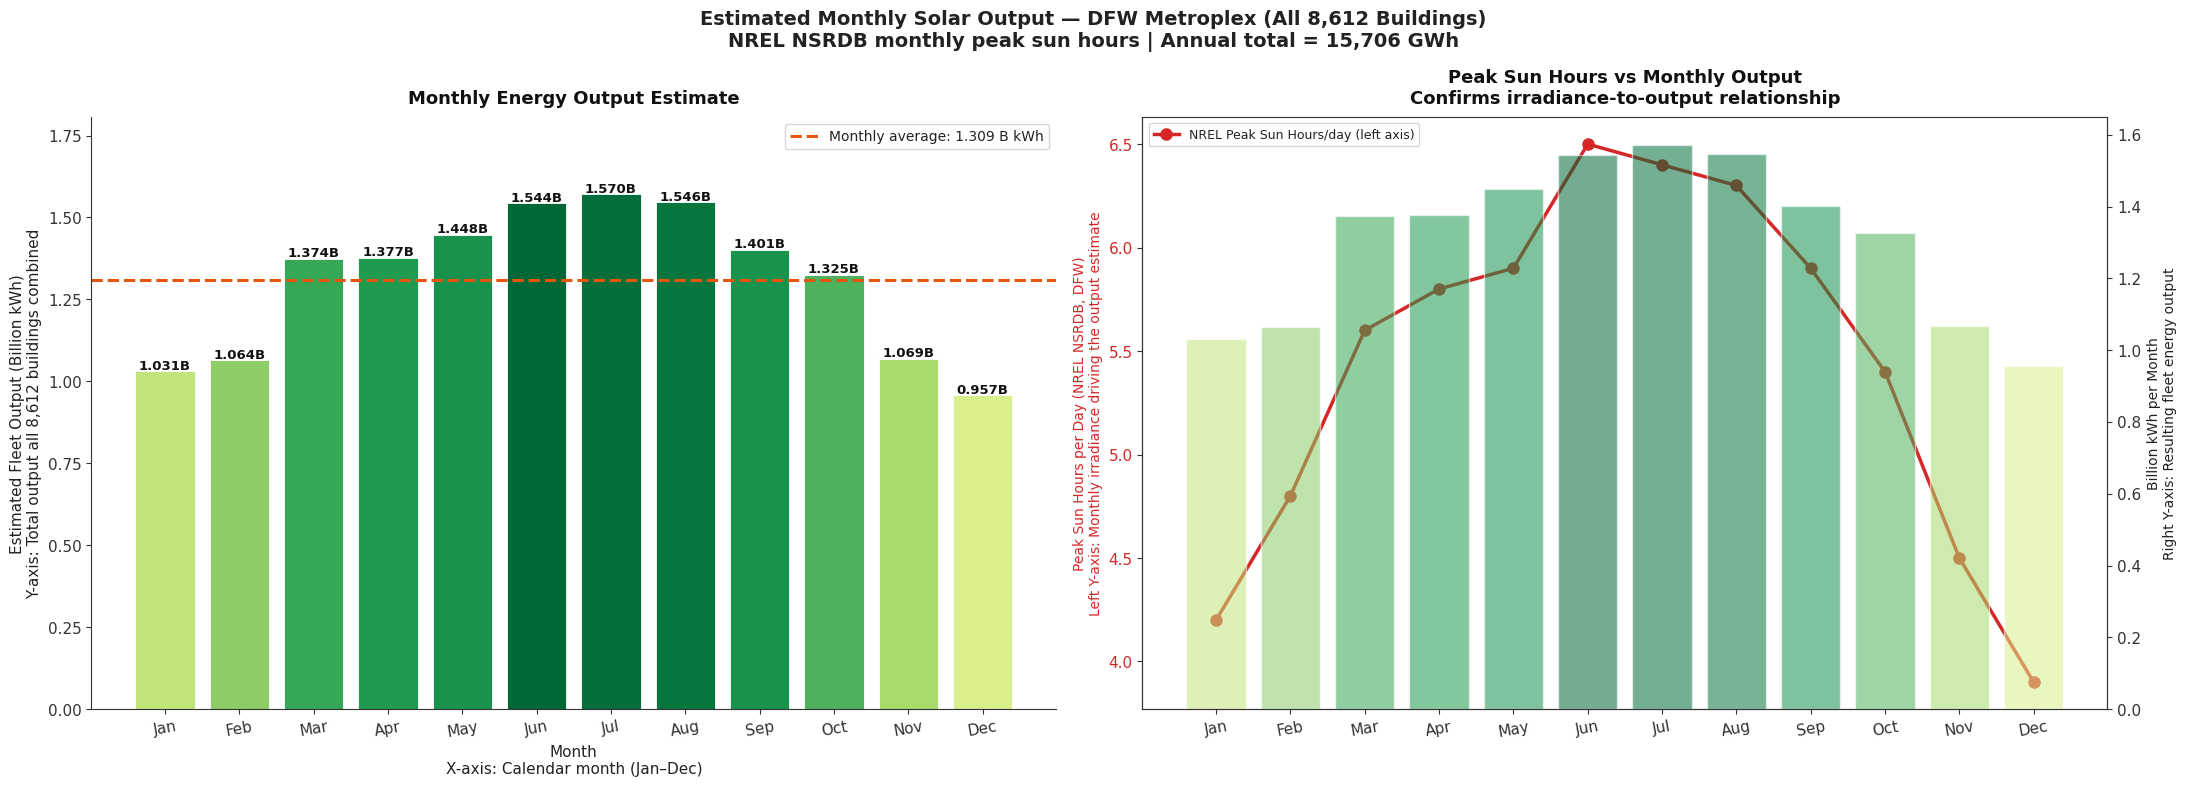

Saved: 14_seasonal_output.png
Annual total check: 15.7057 B kWh (matches dataset: 15.7057 B kWh)


In [ ]:
# ── Estimated monthly solar output ───────────────────────────────────────────
months     = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
peak_sun   = [4.2, 4.8, 5.6, 5.8, 5.9, 6.5, 6.4, 6.3, 5.9, 5.4, 4.5, 3.9]
days_in_mo = [31,  28,  31,  30,  31,  30,  31,  31,  30,  31,  30,  31 ]

# Correct approach: distribute the ACTUAL annual total proportionally
# by (peak_sun × days) weight — so monthly values sum exactly to the dataset annual total
weights        = [ps * d for ps, d in zip(peak_sun, days_in_mo)]
total_weight   = sum(weights)
annual_kwh     = df['Annual_kWh'].sum()          # 15,705,714,610 kWh — from dataset
monthly_kwh    = [(w / total_weight) * annual_kwh for w in weights]

# Colour: green = high irradiance, yellow-orange = medium, muted = low
clrs_mo = plt.cm.RdYlGn([ps / max(peak_sun) for ps in peak_sun])

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('Estimated Monthly Solar Output — DFW Metroplex (All 8,612 Buildings)\n'
             'NREL NSRDB monthly peak sun hours | Annual total = 15,706 GWh',
             fontsize=14, fontweight='bold')

# ── Panel 1 — bar chart ───────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(months, [m / 1e9 for m in monthly_kwh],
              color=clrs_mo, edgecolor='white', linewidth=0.6)
for bar, val in zip(bars, [m / 1e9 for m in monthly_kwh]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
            f'{val:.3f}B', ha='center', fontsize=9.5,
            color='#111111', fontweight='bold')
avg_monthly = sum(monthly_kwh) / 12 / 1e9
ax.axhline(avg_monthly, color='#e6550d', lw=2.2, ls='--',
           label=f'Monthly average: {avg_monthly:.3f} B kWh')
ax.set_title('Monthly Energy Output Estimate', fontweight='bold', pad=10)
ax.set_xlabel('Month\nX-axis: Calendar month (Jan–Dec)', fontsize=11)
ax.set_ylabel('Estimated Fleet Output (Billion kWh)\n'
              'Y-axis: Total output all 8,612 buildings combined', fontsize=11)
ax.set_ylim(0, max([m / 1e9 for m in monthly_kwh]) * 1.15)
ax.tick_params(axis='x', rotation=10)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2 — dual axis ───────────────────────────────────────────────────────
ax = axes[1]
ax.plot(months, peak_sun, color='#d62728', lw=2.5, marker='o',
        markersize=8, label='NREL Peak Sun Hours/day (left axis)')
ax.set_ylabel('Peak Sun Hours per Day (NREL NSRDB, DFW)\n'
              'Left Y-axis: Monthly irradiance driving the output estimate',
              fontsize=10, color='#d62728')
ax.tick_params(axis='y', labelcolor='#d62728')
ax2 = ax.twinx()
ax2.bar(months, [m / 1e9 for m in monthly_kwh],
        color=clrs_mo, alpha=0.55, edgecolor='white')
ax2.set_ylabel('Billion kWh per Month\n'
               'Right Y-axis: Resulting fleet energy output', fontsize=10)
ax.set_title('Peak Sun Hours vs Monthly Output\n'
             'Confirms irradiance-to-output relationship', fontweight='bold', pad=10)
ax.tick_params(axis='x', rotation=10)
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top']].set_visible(False)

plt.tight_layout()
plt.savefig('14_seasonal_output.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: 14_seasonal_output.png")
print(f"Annual total check: {sum(monthly_kwh)/1e9:.4f} B kWh (matches dataset: {annual_kwh/1e9:.4f} B kWh)")

## Download All Charts

In [ ]:
import zipfile, os
from google.colab import files

charts = [
    '01_building_type.png',
    '01b_county_panels.png',
    '02_building_type_pie.png',
    '03_county_analysis.png',
    '05_pareto_energy.png',
    '06_building_size_dist.png',
    '07_carbon_analysis.png',
    '08_cost_analysis.png',
    '09_household_scatter.png',
    '10_ev_analysis.png',
    '12_pearson_correlation.png',
    '14_seasonal_output.png',
]

zip_name = 'DFW_Solar_Final_Charts.zip'
found, missing = [], []
with zipfile.ZipFile(zip_name, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for chart in charts:
        if os.path.exists(chart):
            zf.write(chart); found.append(chart)
            print(f'  OK  {chart}')
        else:
            missing.append(chart)
            print(f'  MISSING  {chart}  — run that section first')

print(f'\n{len(found)}/{len(charts)} charts zipped')
files.download(zip_name)
print('Download started!')

  OK  01_building_type.png
  OK  01b_county_panels.png
  OK  02_building_type_pie.png
  OK  03_county_analysis.png
  OK  05_pareto_energy.png
  OK  06_building_size_dist.png
  OK  07_carbon_analysis.png
  OK  08_cost_analysis.png
  OK  09_household_scatter.png
  OK  10_ev_analysis.png
  OK  12_pearson_correlation.png
  OK  14_seasonal_output.png

12/12 charts zipped


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!
